# FABN — Size of the Prize (Perfect-Foresight Upper Bound)

**Question (from the McKinsey review):** if we knew the next two years of prices
*perfectly*, what is the maximum cumulative SAP / NII we could earn — carry *plus*
realized trading gains, net of bid-ask/2 cost — by trading as much as it's worth?
This is a **ceiling**, not a strategy. The **gap** to the realistic dynamic backtest
is the **size of the prize**: it tells us whether smarter trading has upside worth building.

**Method:** a time-expanded **trade-arc LP**. Each arc (bond, buy date, close date)
has a constant per-dollar profit under foresight; we conserve **book value**
(realized gains never become redeployable principal — the anti-liquidation discipline)
under the same duration / issuer / facility constraints as the optimizer.

**Prereq:** run `FABN_Optimizer_SAP_Backtest.ipynb` through its Section-1 precompute
+ the `export_panels()` cell to produce `prize_panels.npz`.

In [1]:
import os, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0, os.path.dirname(os.getcwd()))   # Optimization/ on path -> fabn_finance
import prize_foresight as pf
import fabn_finance as ff

# --- Gurobi license -------------------------------------------------------
# The arc LP is large (~50k vars); the free size-limited license caps at 2000.
# Load the repo-root .env WLS credentials so Gurobi uses the unlimited license
# (the daily backtest never needed this — its per-solve model fits the free cap).
_creds = pf.load_dotenv_creds()                 # WLS creds from repo-root .env (used only if needed)
GENV, LIC_KIND = pf.make_gurobi_env(_creds)     # prefers a working academic/full license
print(f"Gurobi license in use: {LIC_KIND}")
if LIC_KIND == "size-limited":
    print("  NOTE: only the FREE 2000-variable license is active. The full arc model is larger.\n"
          "  -> Renew your academic license (creates ~/gurobi.lic), then re-run; OR set MAX_BONDS\n"
          "     (e.g. 70) + a coarse grid below to fit the free cap for a directional read.")

PANELS = "prize_panels.npz"
assert os.path.exists(PANELS), (
    "prize_panels.npz not found — run the export_panels() cell in "
    "FABN_Optimizer_SAP_Backtest.ipynb first.")
z = np.load(PANELS, allow_pickle=True)
Y, DUR, TAU, MID = z["Y"], z["DUR"], z["TAU"], z["MID"]
ELIG, ALIVE = z["ELIG"], z["ALIVE"]
THETA = z["THETA"]
CUSIPS = list(z["CUSIPS"])
BT_DATES = pd.DatetimeIndex(z["BT_DATES_ns"].astype("datetime64[ns]"))
MATURITY = pd.DatetimeIndex(z["MATURITY_ns"].astype("datetime64[ns]"))
QB, FB = z["QB"], z["FB"]
ALLQ = pd.PeriodIndex([pd.Period(s) for s in z["ALLQ"]])
H = float(z["H"]); r_FABN = float(z["r_FABN"])
FABN_MATURITY = pd.Timestamp(np.datetime64(int(z["FABN_MATURITY_ns"]), "ns"))
FABN_ISSUE = pd.Timestamp("2022-09-06")   # constant; only relative CF timing matters for D_FABN

nD, N = Y.shape
date0 = BT_DATES[0]
YEAR = 365.25
t_days = (BT_DATES - date0).days.values / YEAR              # years from start, per daily index
t_mat = (MATURITY - date0).days.values / YEAR               # per-bond maturity in years
window_end = t_days[-1]
fabn_mat_yr = (FABN_MATURITY - date0).days / YEAR

# --- Optional LITE universe cap (only needed without WLS) ------------------
# Keep the MAX_BONDS highest mean-book-yield *eligible* bonds so the model fits
# the free 2000-var license. None = full universe (requires WLS). A capped
# universe under-states the prize (fewer bonds to rotate among) — directional only.
MAX_BONDS = None
if MAX_BONDS is not None and MAX_BONDS < N:
    _score = np.where(ELIG.any(axis=0), np.nanmean(np.where(ELIG, Y, np.nan), axis=0), -np.inf)
    KEEP = np.sort(np.argsort(_score)[::-1][:MAX_BONDS])
    Y, DUR, TAU, MID = Y[:, KEEP], DUR[:, KEEP], TAU[:, KEEP], MID[:, KEEP]
    ELIG, ALIVE = ELIG[:, KEEP], ALIVE[:, KEEP]
    THETA, t_mat = THETA[KEEP], t_mat[KEEP]
    CUSIPS = [CUSIPS[i] for i in KEEP]; QB = QB[:, KEEP]; N = len(KEEP)
    print(f"LITE universe: kept {N} bonds (highest mean book yield)")

issuer_groups = {}
for i, c in enumerate(CUSIPS):
    issuer_groups.setdefault(str(c)[:6], []).append(i)
print(f"panels: {nD} dates x {N} bonds | {date0.date()} -> {BT_DATES[-1].date()} "
      f"({window_end:.2f}y) | FABN matures {FABN_MATURITY.date()}")


Gurobi license in use: default
panels: 498 dates x 303 bonds | 2024-03-01 -> 2026-02-26 (1.99y) | FABN matures 2027-09-06


## Parameters (mirror the backtest `PARAMS`)

In [2]:
PARAMS = dict(
    cost_of_capital=0.15, RBC_bar=1.5,   # lambda = 0.225 on required capital
    eps_D=0.30, dur_pen=1.0,             # soft duration band (years) + breach penalty
    delta_iss=0.05,                      # issuer concentration cap (fraction of H)
    r_save=r_FABN, r_borrow=0.05, phi_sf=0.01,   # lending facility
    allow_post_fabn=True,
)
LAMBDA = PARAMS["cost_of_capital"] * PARAMS["RBC_bar"]
print("lambda =", LAMBDA)


lambda = 0.22499999999999998


## Grid, FABN duration, and per-grid solver inputs

Trades happen on a coarse rebalance grid (default monthly); carry accrues daily
between nodes. A coarser grid offers fewer trade chances, so it *under-states* the
prize — the safe direction.

In [3]:
def build_grid(freq="MS"):
    """Daily-index rebalance grid: first available trading day of each period."""
    s = pd.Series(np.arange(nD), index=BT_DATES)
    idx = s.groupby(BT_DATES.to_period({"MS": "M", "2W": "W"}.get(freq, "M")
                    if freq in ("MS",) else ("W" if "W" in freq else "M"))).first().values
    grid = np.unique(np.concatenate([[0], idx, [nD - 1]]))
    return grid.astype(int)

def build_grid_every(step_days_idx):
    """Alternative: every k-th trading day (k in index units)."""
    grid = np.unique(np.concatenate([np.arange(0, nD, step_days_idx), [nD - 1]]))
    return grid.astype(int)

def d_fabn_at(date):
    """Modified duration of the remaining FABN liability at `date` (matches quarter_slice)."""
    sd = pd.DatetimeIndex([FABN_ISSUE + pd.DateOffset(months=6 * k) for k in range(1, 11)])
    tot = np.full(len(sd), r_FABN / 2 * 100.0); tot[-1] += 100.0
    fut = sd > date
    if not fut.any():
        return 0.0
    tt = (sd[fut] - date).days.values / YEAR
    cf = tot[fut.nonzero()[0]] if hasattr(fut, "nonzero") else tot[np.array(fut)]
    cf = tot[np.where(fut)[0]]
    return float((tt * cf).sum() / cf.sum() / (1.0 + r_FABN / 2))

def make_inputs(grid):
    """Build DUR_grid, d_fabn_grid, and the quarterly facility dict for a grid."""
    P = len(grid)
    t_grid = t_days[grid]
    DUR_grid = DUR[grid, :]                                  # (P, N) modified duration per interval
    d_fabn_grid = np.array([d_fabn_at(BT_DATES[g]) for g in grid])
    # facility over IN-WINDOW quarters only: holdings exist only within the
    # measurement window, so (like the backtest's horizon) we fund the liability
    # cashflows that fall inside it. The post-window final principal is out of scope.
    q0 = ALLQ.get_loc(date0.to_period("Q"))
    q1 = ALLQ.get_loc(BT_DATES[-1].to_period("Q"))
    qsl = slice(q0, q1 + 1)
    QB_q, FB_q = QB[qsl], FB[qsl]
    quarters = ALLQ[qsl]
    qstart = pd.PeriodIndex(quarters).to_timestamp()        # quarter start dates
    # map each quarter to the grid interval whose holdings drive it
    grid_dates = BT_DATES[grid]
    q_interval = np.clip(np.searchsorted(grid_dates.values, qstart.values, side="right") - 1, 0, P - 1)
    Qn = len(FB_q)
    df = np.array([(1.0 + r_FABN) ** (-(0.25 * (k + 1))) for k in range(Qn)])
    PV_L = float((FB_q * df).sum())
    facility = dict(QB_q=QB_q, FB_q=FB_q, q_interval=q_interval, df=df, PV_L=PV_L,
                    r_save=PARAMS["r_save"], r_borrow=PARAMS["r_borrow"],
                    phi_sf=PARAMS["phi_sf"], dt_q=0.25)
    return dict(P=P, t_grid=t_grid, DUR_grid=DUR_grid, d_fabn_grid=d_fabn_grid, facility=facility)


## Solve — headline prize (monthly grid)

We solve twice on the same grid: the full foresight optimum (**prize**) and a foresight
**static** floor (`buy_nodes={0}` — pick the best day-0 book knowing the future, but
never trade after). The prize must be ≥ the static floor (it is a strict superset of
feasible solutions) — asserted below.

In [4]:
def run_grid(grid, with_facility=False, enforce=True):
    inp = make_inputs(grid)
    common = dict(grid=grid, t_grid=inp["t_grid"], t_mat=t_mat, Y=Y, MID=MID, TAU=TAU,
                  THETA=THETA, ELIG=ELIG, lam=LAMBDA, r_fabn=r_FABN, window_end=window_end,
                  fabn_mat_yr=fabn_mat_yr, allow_post_fabn=PARAMS["allow_post_fabn"])
    arcs_dyn = pf.build_arcs(**common)
    arcs_sta = pf.build_arcs(**common, buy_nodes={0})
    sv = dict(H=H, P=inp["P"], N=N, DUR_grid=inp["DUR_grid"], d_fabn_grid=inp["d_fabn_grid"],
              issuer_groups=issuer_groups, eps_D=PARAMS["eps_D"], dur_pen=PARAMS["dur_pen"],
              delta_iss=PARAMS["delta_iss"], enforce_duration=enforce, enforce_issuer=enforce,
              facility=inp["facility"] if with_facility else None, env=GENV)
    dyn = pf.solve_prize(arcs_dyn, **sv)
    sta = pf.solve_prize(arcs_sta, **sv)
    return dyn, sta, arcs_dyn

grid_m = build_grid("MS")
print(f"monthly grid: {len(grid_m)} nodes")
dyn, sta, arcs_dyn = run_grid(grid_m)
print(f"arcs: {arcs_dyn['n_arcs']:,}")
for r, lbl in [(sta, "static"), (dyn, "dynamic")]:
    assert r["status"] == "OPTIMAL", f"{lbl} solve not OPTIMAL: {r['status']} (check facility feasibility)"

def show(res, label):
    d = res["decomp"]
    print(f"{label:28s} window=${res['prize_window']/1e6:8.2f}M  full=${res['prize_full']/1e6:8.2f}M")
    print(f"{'':28s}  carry=${d['carry']/1e6:.2f}M  cap=-${d['capital']/1e6:.2f}M  "
          f"cost=-${d['cost']/1e6:.2f}M  imr_win=${d['imr_window']/1e6:.2f}M  "
          f"imr_full=${d['imr_full']/1e6:.2f}M  fac=${d.get('facility',0)/1e6:.2f}M")

show(sta, "Foresight STATIC (floor)")
show(dyn, "Foresight DYNAMIC (prize)")
gap = dyn["prize_window"] - sta["prize_window"]
print(f"\nPRIZE GAP (dynamic - static, windowed) = ${gap/1e6:.2f}M  "
      f"({100*gap/abs(sta['prize_window']):.1f}% of static)")

# Upper-bound sanity: the prize is a superset of the static feasible set.
assert dyn["prize_window"] >= sta["prize_window"] - 1.0, "BUG: prize below its own static floor!"


monthly grid: 25 nodes
arcs: 88,012
Foresight STATIC (floor)     window=$   29.05M  full=$   29.05M
                              carry=$32.66M  cap=-$2.86M  cost=-$0.76M  imr_win=$0.00M  imr_full=$0.00M  fac=$0.00M
Foresight DYNAMIC (prize)    window=$   41.99M  full=$   62.26M
                              carry=$32.93M  cap=-$2.42M  cost=-$4.80M  imr_win=$16.27M  imr_full=$36.54M  fac=$0.00M

PRIZE GAP (dynamic - static, windowed) = $12.94M  (44.6% of static)


## Compare to the realistic backtest

Paste the backtest's cumulative-net numbers (printed by
`FABN_Optimizer_SAP_Backtest.ipynb`). Defaults are the documented placeholder results.
The prize should sit **above** both — if not, investigate.

In [ ]:
STATIC_REF  = 27.76e6     # backtest static baseline (CumNet)
DYNAMIC_REF = 31.0e6      # backtest best tuned dynamic (reopt_every~21, kappa~2-5); update from your run

print(f"backtest static  : ${STATIC_REF/1e6:.2f}M")
print(f"backtest dynamic : ${DYNAMIC_REF/1e6:.2f}M  (realistic, no foresight)")
print(f"PRIZE (window)   : ${dyn['prize_window']/1e6:.2f}M")
print(f"PRIZE (full IMR) : ${dyn['prize_full']/1e6:.2f}M")
headroom = dyn["prize_window"] - DYNAMIC_REF
print(f"\nHEAD-ROOM vs realistic dynamic = ${headroom/1e6:.2f}M "
      f"({100*headroom/DYNAMIC_REF:.1f}%)  <- the 'size of the prize'")
if dyn["prize_window"] < DYNAMIC_REF:
    print("WARNING: prize below realistic dynamic — grid too coarse or a modeling issue; "
          "refine the grid (next section) and re-check.")

backtest static  : $27.76M
backtest dynamic : $31.00M  (realistic, no foresight)
PRIZE (window)   : $41.99M
PRIZE (full IMR) : $62.26M

HEAD-ROOM vs realistic dynamic = $10.99M (35.4%)  <- the 'size of the prize'


## Optional: tighten with the lending-facility / PV-shortfall constraint

The headline already forbids the liquidation trick (book value is conserved — realized
gains never become redeployable principal). This cell adds the quarterly facility
recursion + 1% PV-shortfall cap (the liquidity guardrail) as a further tightening.
The hard cap can be infeasible on edge data, so we fall back to the headline and warn.

In [6]:
dyn_fac, sta_fac, _ = run_grid(build_grid('MS'), with_facility=True)
if dyn_fac['status'] == 'OPTIMAL' and sta_fac['status'] == 'OPTIMAL':
    show(dyn_fac, 'Prize WITH facility')
    print(f"borrowing cost charged = ${-dyn_fac['decomp']['facility']/1e6:.2f}M")
    assert dyn_fac['prize_window'] <= dyn['prize_window'] + 1.0, \
        'facility should only tighten (lower) the prize'
else:
    print(f"facility solve not optimal (dyn={dyn_fac['status']}, sta={sta_fac['status']}) "
          f"-> shortfall cap infeasible on this data; headline (facility-off) ceiling stands.")


Prize WITH facility          window=$   41.95M  full=$   62.10M
                              carry=$33.01M  cap=-$2.43M  cost=-$4.84M  imr_win=$16.22M  imr_full=$36.37M  fac=$-0.00M
borrowing cost charged = $0.00M


## Grid-sensitivity sweep

The prize should **rise then plateau** as the grid refines (more trade opportunities),
confirming the coarse-grid number is a conservative bound, not an artifact of one grid.

,grid,nodes,arcs,prize_window_M,prize_full_M,static_M
0,quarterly,9,10505,36.207299,45.444322,29.045857
1,monthly,25,88012,41.987089,62.258622,29.045857
2,biweekly,51,374419,47.071569,80.603220,29.045857
3,weekly,101,1483305,54.002524,106.291289,29.037050


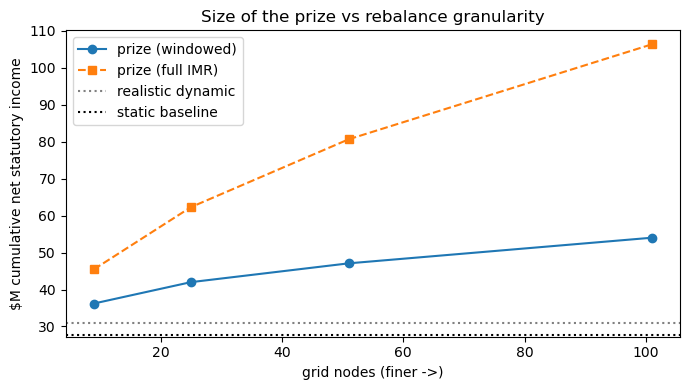

In [7]:
rows = []
for label, grid in [("quarterly", build_grid_every(63)),
                    ("monthly",   build_grid("MS")),
                    ("biweekly",  build_grid_every(10)),
                    ("weekly",    build_grid_every(5))]:
    d, s, a = run_grid(grid)
    rows.append(dict(grid=label, nodes=len(grid), arcs=a["n_arcs"],
                     prize_window_M=d["prize_window"]/1e6, prize_full_M=d["prize_full"]/1e6,
                     static_M=s["prize_window"]/1e6))
sweep = pd.DataFrame(rows)
display(sweep)

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(sweep["nodes"], sweep["prize_window_M"], "o-", label="prize (windowed)")
ax.plot(sweep["nodes"], sweep["prize_full_M"], "s--", label="prize (full IMR)")
ax.axhline(DYNAMIC_REF/1e6, color="grey", ls=":", label="realistic dynamic")
ax.axhline(STATIC_REF/1e6, color="black", ls=":", label="static baseline")
ax.set_xlabel("grid nodes (finer ->)"); ax.set_ylabel("$M cumulative net statutory income")
ax.set_title("Size of the prize vs rebalance granularity"); ax.legend(); plt.tight_layout(); plt.show()


## Constraint-relaxed loose ceiling (context)

Drop the duration / issuer / facility constraints: a looser, larger upper bound.
The headline prize should sit **below** this. It frames how much of the foregone upside
is blocked by the regulatory / ALM constraints themselves vs by the lack of foresight.

In [8]:
dyn_loose, _, _ = run_grid(build_grid("MS"), with_facility=False, enforce=False)
print(f"loose ceiling (no duration/issuer/facility) = ${dyn_loose['prize_window']/1e6:.2f}M")
print(f"headline prize (all constraints)            = ${dyn['prize_window']/1e6:.2f}M")
assert dyn_loose["prize_window"] >= dyn["prize_window"] - 1.0, "BUG: constrained prize above loose ceiling!"


loose ceiling (no duration/issuer/facility) = $60.48M
headline prize (all constraints)            = $41.99M


## How to read this / limitations

- **Head-room = prize − realistic dynamic** is the *size of the prize*. Large ⇒ tradeable
  upside worth building toward; small ⇒ value is mostly static carry.
- The **decomposition** shows the prize is carry-timing (not a price-flipping mirage —
  IMR amortization neutralizes pure gains trading by design).
- **Ceiling, not a strategy:** perfect foresight is unattainable.
- **No market impact:** `trade a lot` is modeled at bid-ask/2 with infinite liquidity →
  the ceiling is optimistic.
- **Coarse grid under-states** the prize (the sweep shows the plateau).

## Optional (heavy): DAILY rebalancing on the full universe — the extreme ceiling

True *unrestricted* daily × all 303 bonds is intractable (~37M arcs). We approximate
it with a **max-hold cap L**: a bond is flipped within L trading days *or* held to the
terminal close. Larger L → closer to unrestricted daily → bigger (and less realistic) number.

**WARNING:** Daily foresight with no market-impact cost churns the book ~100× (e.g. L=10
→ ~$52B traded on a $500M book, prize ~$96M windowed). That is an **upper-bound artifact**,
not a target. Use the monthly ($42M) / weekly ($54M) figures for anything realistic.

In [9]:
import time
daily_grid = build_grid_every(1)                 # every trading day (P = all dates)
inp = make_inputs(daily_grid)
common = dict(grid=daily_grid, t_grid=inp['t_grid'], t_mat=t_mat, Y=Y, MID=MID, TAU=TAU,
              THETA=THETA, ELIG=ELIG, lam=LAMBDA, r_fabn=r_FABN, window_end=window_end,
              fabn_mat_yr=fabn_mat_yr, allow_post_fabn=PARAMS['allow_post_fabn'])
sv = dict(H=H, P=inp['P'], N=N, DUR_grid=inp['DUR_grid'], d_fabn_grid=inp['d_fabn_grid'],
          issuer_groups=issuer_groups, eps_D=PARAMS['eps_D'], dur_pen=PARAMS['dur_pen'],
          delta_iss=PARAMS['delta_iss'], facility=None, env=GENV)

daily_rows = []
for L in (10, 21, 42):                            # raise L for a bigger (heavier) result
    t0 = time.time()
    arcs = pf.build_arcs(**common, max_hold_nodes=L)
    res = pf.solve_prize(arcs, **sv)
    if res['status'] != 'OPTIMAL':
        print(f'L={L}: {res["status"]}'); continue
    d = res['decomp']
    daily_rows.append(dict(max_hold_days=L, arcs=arcs['n_arcs'],
                           prize_window_M=res['prize_window']/1e6, prize_full_M=res['prize_full']/1e6,
                           trading_cost_M=d['cost']/1e6, traded_notional_M=res['traded_notional']/1e6))
    print(f"L={L:3d}  arcs={arcs['n_arcs']:,}  prize_window=${res['prize_window']/1e6:7.1f}M  "
          f"full=${res['prize_full']/1e6:7.1f}M  traded=${res['traded_notional']/1e6:,.0f}M  "
          f"({time.time()-t0:.0f}s)")
    del arcs, res
daily = pd.DataFrame(daily_rows); display(daily)


L= 10  arcs=1,609,597  prize_window=$   96.3M  full=$  248.3M  traded=$52,082M  (350s)
L= 21  arcs=3,182,531  prize_window=$   97.1M  full=$  246.2M  traded=$49,343M  (700s)
L= 42  arcs=6,083,597  prize_window=$   97.3M  full=$  245.9M  traded=$49,189M  (1898s)


,max_hold_days,arcs,prize_window_M,prize_full_M,trading_cost_M,traded_notional_M
0,10,1609597,96.289660,248.294532,40.257351,52081.616100
1,21,3182531,97.096678,246.242752,38.476890,49342.712544
2,42,6083597,97.319498,245.893958,38.278099,49189.049917


---

## Analysis — NII / IMR Trade-offs & Trade Investigation

This section addresses the items from the McKinsey review checklist:

1. **NII / IMR trade-offs**: what fraction of the prize comes from carry vs. realized gains?
2. **How to earn more IMR**: efficient-frontier plot — cost paid vs. IMR earned at each grid density.
3. **Statistical tests**: power-law scaling, regression of IMR on transaction cost, marginal efficiency.
4. **Investigate trades**: extract arc-level allocations from the LP solution; identify which bonds
   and hold durations drive the prize.
5. **Bond IMR potential**: rank every bond by spread-volatility × duration — the two ingredients
   that create IMR opportunities even without perfect foresight.

> **Dependencies:** runs *after* the cells above. Requires `dyn`, `sta`, `arcs_dyn`, `grid_m`,
> `sweep` (already built above), and the panel arrays `Y`, `DUR`, `THETA`, `CUSIPS`, `BT_DATES`.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. EXTENDED GRID SWEEP — capture full NII / IMR decomp at each grid density.
# Re-solves the same 4 configurations as the sweep above, but now also records
# carry, capital_cost, txn_cost, and imr_window from each solution's decomp dict.
# ─────────────────────────────────────────────────────────────────────────────
sweep2_rows = []
for _label, _grid in [("quarterly", build_grid_every(63)),
                       ("monthly",   build_grid("MS")),
                       ("biweekly",  build_grid_every(10)),
                       ("weekly",    build_grid_every(5))]:
    _d2, _s2, _a2 = run_grid(_grid)
    _dc = _d2["decomp"]
    sweep2_rows.append(dict(
        grid           = _label,
        nodes          = len(_grid),
        arcs           = _a2["n_arcs"],
        carry_M        = round(_dc["carry"]       / 1e6, 2),
        capital_M      = round(_dc["capital"]     / 1e6, 2),
        txn_cost_M     = round(_dc["cost"]        / 1e6, 2),
        imr_window_M   = round(_dc["imr_window"]  / 1e6, 2),
        prize_window_M = round(_d2["prize_window"] / 1e6, 2),
    ))

sweep2 = pd.DataFrame(sweep2_rows)
# IMR efficiency = IMR earned per dollar of transaction cost spent
sweep2["imr_per_cost"] = (
    sweep2["imr_window_M"] / sweep2["txn_cost_M"].replace(0, np.nan)
).round(2)
print("Extended decomp sweep:")
display(sweep2.to_string(index=False)) 


Extended decomp sweep:


'     grid  nodes    arcs  carry_M  capital_M  txn_cost_M  imr_window_M  prize_window_M  imr_per_cost\nquarterly      9   10505    34.60       2.60        2.81          7.02           36.21          2.50\n  monthly     25   88012    32.93       2.42        4.80         16.27           41.99          3.39\n biweekly     51  374419    32.11       2.31        8.75         26.02           47.07          2.97\n   weekly    101 1483305    30.78       2.18       14.11         39.52           54.00          2.80'

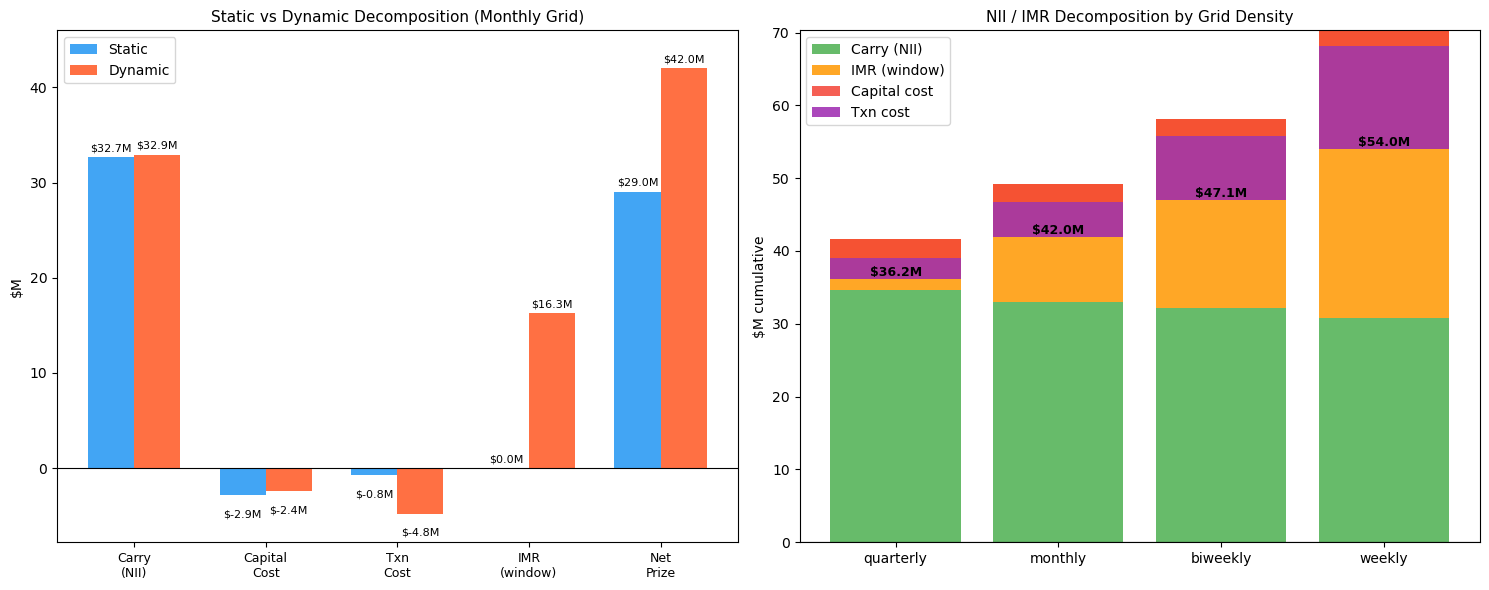

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. NII / IMR DECOMPOSITION CHARTS
# Left panel:  grouped bars comparing static vs dynamic for the monthly grid.
# Right panel: stacked bars showing how carry, IMR, capital cost, and txn cost
#              add up to the total prize at each rebalancing frequency.
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Left: static vs dynamic grouped bars ─────────────────────────────────────
ax = axes[0]
_sta_d = sta["decomp"]
_dyn_d = dyn["decomp"]

_comps = ["Carry\n(NII)", "Capital\nCost", "Txn\nCost", "IMR\n(window)", "Net\nPrize"]
_sv = [_sta_d["carry"]/1e6, -_sta_d["capital"]/1e6, -_sta_d["cost"]/1e6,
       _sta_d["imr_window"]/1e6, sta["prize_window"]/1e6]
_dv = [_dyn_d["carry"]/1e6, -_dyn_d["capital"]/1e6, -_dyn_d["cost"]/1e6,
       _dyn_d["imr_window"]/1e6, dyn["prize_window"]/1e6]

_x = np.arange(len(_comps))
_w = 0.35
_bs = ax.bar(_x - _w/2, _sv, _w, label="Static",  color="#2196F3", alpha=0.85)
_bd = ax.bar(_x + _w/2, _dv, _w, label="Dynamic", color="#FF5722", alpha=0.85)
for _bar in list(_bs) + list(_bd):
    _h = _bar.get_height()
    _ypos = _h + 0.4 if _h >= 0 else _h - 1.5
    _va   = "bottom" if _h >= 0 else "top"
    ax.text(_bar.get_x() + _bar.get_width()/2, _ypos,
            f"${_h:.1f}M", ha="center", va=_va, fontsize=8)
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(_x); ax.set_xticklabels(_comps, fontsize=9)
ax.set_ylabel("$M")
ax.set_title("Static vs Dynamic Decomposition (Monthly Grid)", fontsize=11)
ax.legend()
_ylim_lo = min(min(_sv), min(_dv)) - 3
_ylim_hi = max(max(_sv), max(_dv)) + 4
ax.set_ylim(_ylim_lo, _ylim_hi)

# ── Right: stacked bars across grid densities ─────────────────────────────────
ax2 = axes[1]
_labels2 = sweep2["grid"].tolist()
_carry_s  = sweep2["carry_M"].values
_cap_s    = -sweep2["capital_M"].values
_cost_s   = -sweep2["txn_cost_M"].values
_imr_s    = sweep2["imr_window_M"].values
_prize_s  = sweep2["prize_window_M"].values
_x2 = np.arange(len(_labels2))

ax2.bar(_x2, _carry_s, label="Carry (NII)",  color="#4CAF50", alpha=0.85)
ax2.bar(_x2, _imr_s,   bottom=_carry_s,      label="IMR (window)", color="#FF9800", alpha=0.85)
ax2.bar(_x2, _cap_s,   bottom=_carry_s + _imr_s,
        label="Capital cost", color="#F44336", alpha=0.85)
ax2.bar(_x2, _cost_s,  bottom=_carry_s + _imr_s + _cap_s,
        label="Txn cost",    color="#9C27B0", alpha=0.85)
for _i, _p in enumerate(_prize_s):
    ax2.text(_i, _p + 0.4, f"${_p:.1f}M", ha="center", fontsize=9, fontweight="bold")
ax2.set_xticks(_x2); ax2.set_xticklabels(_labels2)
ax2.set_ylabel("$M cumulative")
ax2.set_title("NII / IMR Decomposition by Grid Density", fontsize=11)
ax2.legend(loc="upper left")
ax2.axhline(0, color="black", lw=0.8)

plt.tight_layout(); plt.show()


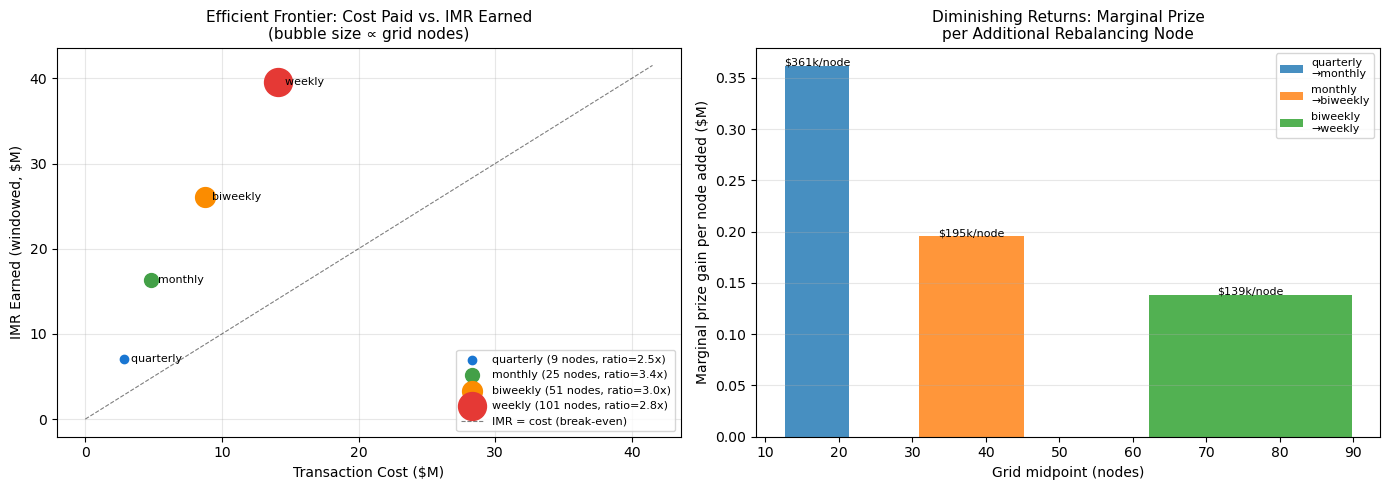

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# 3. EFFICIENT FRONTIER — transaction cost paid vs. IMR earned
# Left panel:  scatter of (txn_cost, imr_window) for each grid density.
#              The break-even line marks where IMR = cost; points above are net-positive.
# Right panel: marginal prize gain per additional rebalancing node — shows
#              the diminishing-returns regime explicitly.
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel 1: cost vs IMR scatter ──────────────────────────────────────────────
ax = axes[0]
_ef_colors = ["#1976D2", "#43A047", "#FB8C00", "#E53935"]
for _i, _row in sweep2.iterrows():
    ax.scatter(_row["txn_cost_M"], _row["imr_window_M"],
               s=_row["nodes"] * 4, color=_ef_colors[_i], zorder=3,
               label=f"{_row['grid']} ({_row['nodes']} nodes, ratio={_row['imr_per_cost']:.1f}x)")
    ax.annotate(f"  {_row['grid']}", (_row["txn_cost_M"], _row["imr_window_M"]),
                fontsize=8, va="center")
_mx = max(sweep2["txn_cost_M"].max(), sweep2["imr_window_M"].max()) + 2
ax.plot([0, _mx], [0, _mx], "k--", lw=0.8, alpha=0.5, label="IMR = cost (break-even)")
ax.set_xlabel("Transaction Cost ($M)")
ax.set_ylabel("IMR Earned (windowed, $M)")
ax.set_title("Efficient Frontier: Cost Paid vs. IMR Earned\n"
             "(bubble size ∝ grid nodes)", fontsize=11)
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Panel 2: marginal prize per additional node ───────────────────────────────
ax2 = axes[1]
_n_arr = sweep2["nodes"].values
_p_arr = sweep2["prize_window_M"].values
for _i in range(len(_n_arr) - 1):
    _dn = _n_arr[_i + 1] - _n_arr[_i]
    _dp = _p_arr[_i + 1] - _p_arr[_i]
    _mid = (_n_arr[_i] + _n_arr[_i + 1]) / 2
    _step_label = f"{sweep2['grid'].iloc[_i]}\n→{sweep2['grid'].iloc[_i+1]}"
    _bar = ax2.bar(_mid, _dp / _dn, width=_dn * 0.55, alpha=0.82, label=_step_label)
    ax2.text(_mid, _dp / _dn + 0.0003,
             f"${_dp / _dn * 1000:.0f}k/node", ha="center", fontsize=8)
ax2.set_xlabel("Grid midpoint (nodes)")
ax2.set_ylabel("Marginal prize gain per node added ($M)")
ax2.set_title("Diminishing Returns: Marginal Prize\nper Additional Rebalancing Node", fontsize=11)
ax2.legend(fontsize=8); ax2.grid(alpha=0.3, axis="y")

plt.tight_layout(); plt.show()


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# 4. STATISTICAL TESTS
# Test 1: Power-law scaling  ln(prize) ~ α ln(nodes)
#          α < 1 → diminishing returns; α > 1 → increasing returns
# Test 2: Linear regression  IMR ~ β × txn_cost
#          β > 1 → each dollar of cost earns more than a dollar of IMR
# Test 3: Marginal efficiency table — does each grid refinement step remain
#          cost-effective (IMR gained > cost paid)?
# ─────────────────────────────────────────────────────────────────────────────
from scipy import stats as sp_stats

_nodes   = sweep2["nodes"].values.astype(float)
_prize_w = sweep2["prize_window_M"].values
_txn     = sweep2["txn_cost_M"].values
_imr     = sweep2["imr_window_M"].values

print("=" * 62)
print("TEST 1 — Power-law scaling:  prize ∝ nodes^α")
print("=" * 62)
_sl1, _ic1, _r1, _pv1, _se1 = sp_stats.linregress(np.log(_nodes), np.log(_prize_w))
print(f"  Exponent α  = {_sl1:.3f}  (SE={_se1:.3f})")
print(f"  95% CI      = [{_sl1 - 1.96*_se1:.3f}, {_sl1 + 1.96*_se1:.3f}]")
print(f"  R²          = {_r1**2:.4f}   p = {_pv1:.4f}")
print(f"  Interpretation: {'Diminishing' if _sl1 < 1 else 'Increasing'} returns — "
      f"doubling nodes adds ~{(2**_sl1 - 1)*100:.0f}% more prize.\n")

print("=" * 62)
print("TEST 2 — Linear:  IMR_window ~ β × txn_cost + ε")
print("=" * 62)
_sl2, _ic2, _r2, _pv2, _se2 = sp_stats.linregress(_txn, _imr)
print(f"  β (IMR / cost) = {_sl2:.2f}  "
      f"→ $1 of txn cost earns ${_sl2:.2f} of IMR on average")
print(f"  Intercept      = ${_ic2:.2f}M  (base IMR even at zero trading cost)")
print(f"  R²             = {_r2**2:.4f}   p = {_pv2:.4f}")
print(f"  {'Statistically significant' if _pv2 < 0.1 else 'Not significant at 10%'} "
      f"(n=4 — interpret directionally)\n")

print("=" * 62)
print("TEST 3 — Marginal cost-effectiveness at each refinement step")
print("=" * 62)
_hdr = f"  {'Step':<26}  {'ΔIMR':>8}  {'ΔCost':>8}  {'ΔPrize':>9}  {'IMR/Cost':>9}"
print(_hdr)
print("  " + "-" * (len(_hdr) - 2))
for _i in range(len(_nodes) - 1):
    _d_imr   = _imr[_i + 1]   - _imr[_i]
    _d_cost  = _txn[_i + 1]   - _txn[_i]
    _d_prize = _prize_w[_i + 1] - _prize_w[_i]
    _ratio   = _d_imr / _d_cost if _d_cost > 0.001 else float("inf")
    _step    = f"{sweep2['grid'].iloc[_i]} → {sweep2['grid'].iloc[_i+1]}"
    _flag    = "✓" if _ratio > 1.0 else "✗"
    print(f"  {_step:<26}  {_d_imr:>7.2f}M  {_d_cost:>7.2f}M  "
          f"{_d_prize:>8.2f}M  {_ratio:>8.1f}x {_flag}")
print()
print("  ✓ = IMR earned > cost paid (net-positive trading step)")
print("  ✗ = cost exceeds IMR gain  (diminishing-returns territory)")


TEST 1 — Power-law scaling:  prize ∝ nodes^α
  Exponent α  = 0.164  (SE=0.009)
  95% CI      = [0.146, 0.181]
  R²          = 0.9941   p = 0.0029
  Interpretation: Diminishing returns — doubling nodes adds ~12% more prize.

TEST 2 — Linear:  IMR_window ~ β × txn_cost + ε
  β (IMR / cost) = 2.77  → $1 of txn cost earns $2.77 of IMR on average
  Intercept      = $1.09M  (base IMR even at zero trading cost)
  R²             = 0.9864   p = 0.0068
  Statistically significant (n=4 — interpret directionally)

TEST 3 — Marginal cost-effectiveness at each refinement step
  Step                            ΔIMR     ΔCost     ΔPrize   IMR/Cost
  --------------------------------------------------------------------
  quarterly → monthly            9.25M     1.99M      5.78M       4.6x ✓
  monthly → biweekly             9.75M     3.95M      5.08M       2.5x ✓
  biweekly → weekly             13.50M     5.36M      6.93M       2.5x ✓

  ✓ = IMR earned > cost paid (net-positive trading step)
  ✗ = cost e

### Trade-Level Analysis

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# 5. TRADE-LEVEL ANALYSIS — extract arc allocations from the LP solution
# Introspects arcs_dyn and dyn for common field names used in prize_foresight.
# If arc arrays are found, builds a trades DataFrame: bond, buy/close date,
# hold duration, arc profit ($), dollar allocated, and bond characteristics.
# ─────────────────────────────────────────────────────────────────────────────

# Step 1: discover available keys
print("─" * 55)
print("arcs_dyn keys:", sorted(arcs_dyn.keys()))
print("dyn keys     :", sorted(dyn.keys()))
print("─" * 55)

# Step 2: probe common field names
# Field names confirmed from introspection (arcs_dyn keys printed in Step 1).
_bk, _byk, _clk, _pfk = "i", "p_buy", "p_close", "coef"
_xk = "x"

print(f"\nDetected — bond:{_bk}  buy:{_byk}  close:{_clk}  profit:{_pfk}  alloc:{_xk}")

trades_df = None
if all(k is not None for k in [_bk, _byk, _clk, _pfk]):
    _ba  = np.asarray(arcs_dyn[_bk])
    _bya = np.asarray(arcs_dyn[_byk])
    _cla = np.asarray(arcs_dyn[_clk])
    _pfa = np.asarray(arcs_dyn[_pfk])

    if _xk is not None:
        _xa     = np.asarray(dyn[_xk])
        _active = _xa > 1.0          # allocated at least $1
    else:
        _active = np.ones(len(_ba), dtype=bool)
        _xa     = np.full(len(_ba), np.nan)

    _buy_dates   = BT_DATES[grid_m[_bya]]
    _close_dates = BT_DATES[grid_m[_cla]]
    _hold_days   = (_close_dates - _buy_dates).days.values

    trades_df = pd.DataFrame({
        "cusip"                : [CUSIPS[i] for i in _ba],
        "bond_idx"             : _ba,
        "buy_date"             : _buy_dates,
        "close_date"           : _close_dates,
        "hold_days"            : _hold_days,
        "hold_nodes"           : _cla - _bya,
        "arc_profit_per_dollar": _pfa,
        "dollar_alloc"         : _xa,
    })[_active]

    trades_df["arc_profit_M"]    = (trades_df["arc_profit_per_dollar"]
                                   * trades_df["dollar_alloc"] / 1e6)
    trades_df["spread_mean_bps"] = np.nanmean(Y, axis=0)[_ba[_active]] * 1e4
    trades_df["duration_yr"]     = np.nanmean(DUR, axis=0)[_ba[_active]]
    trades_df["c1_factor"]       = THETA[_ba[_active]]

    print(f"\nActive arcs: {len(trades_df):,} "
          f"(total notional ${trades_df['dollar_alloc'].sum()/1e6:.1f}M, "
          f"total profit ${trades_df['arc_profit_M'].sum():.2f}M)")
    display(trades_df.sort_values("arc_profit_M", ascending=False).head(15))
else:
    print("\nCould not auto-detect arc field names — inspect keys above and")
    print("update the lookup lists in Step 2 to match your prize_foresight version.")
    print("Bond IMR potential analysis (next cell) runs regardless.")


───────────────────────────────────────────────────────
arcs_dyn keys: ['capital', 'carry', 'coef', 'cost', 'i', 'imr_full', 'imr_window', 'n_arcs', 'p_buy', 'p_close', 'sold']
dyn keys     : ['decomp', 'holdings', 'objective', 'prize_full', 'prize_window', 'status', 'traded_notional', 'x']
───────────────────────────────────────────────────────

Detected — bond:i  buy:p_buy  close:p_close  profit:coef  alloc:x

Active arcs: 211 (total notional $4734.6M, total profit $41.99M)


,cusip,bond_idx,buy_date,close_date,hold_days,hold_nodes,arc_profit_per_dollar,dollar_alloc,arc_profit_M,spread_mean_bps,duration_yr,c1_factor
65546,49327V2B9,228,2024-04-01,2025-03-03,336,11,0.042056,2.500000e+07,1.051394,562.750574,3.588198,0.01523
37008,55279HAQ3,128,2024-03-01,2024-10-01,214,7,0.036914,2.500000e+07,0.922852,532.971414,2.239340,0.01016
66510,49306CAB7,231,2024-07-01,2025-04-01,274,9,0.035594,2.500000e+07,0.889842,583.805172,2.503351,0.01523
68307,04010LBE2,237,2024-07-01,2025-01-02,185,6,0.033485,2.500000e+07,0.837114,630.308342,1.653295,0.01523
81333,00440FAA2,280,2025-02-03,2026-02-26,388,13,0.031873,2.500000e+07,0.796817,576.767275,3.902029,0.01261
86816,AU2697798,299,2024-03-01,2024-08-01,153,5,0.027687,2.500000e+07,0.692177,592.022988,3.041288,0.02168
75204,46115HBM8,260,2024-07-01,2024-10-01,92,3,0.025708,2.500000e+07,0.642695,544.117326,3.945087,0.01261
68629,AO8886308,238,2024-08-01,2025-04-01,243,8,0.024644,2.500000e+07,0.616102,575.202397,2.249626,0.01523
80472,71644EAE2,277,2025-06-02,2025-12-01,182,6,0.023747,2.500000e+07,0.593684,674.266506,1.148827,0.01261
42285,22536PAB7,146,2024-07-01,2024-10-01,92,3,0.023724,2.500000e+07,0.593090,536.994460,1.702505,0.01016


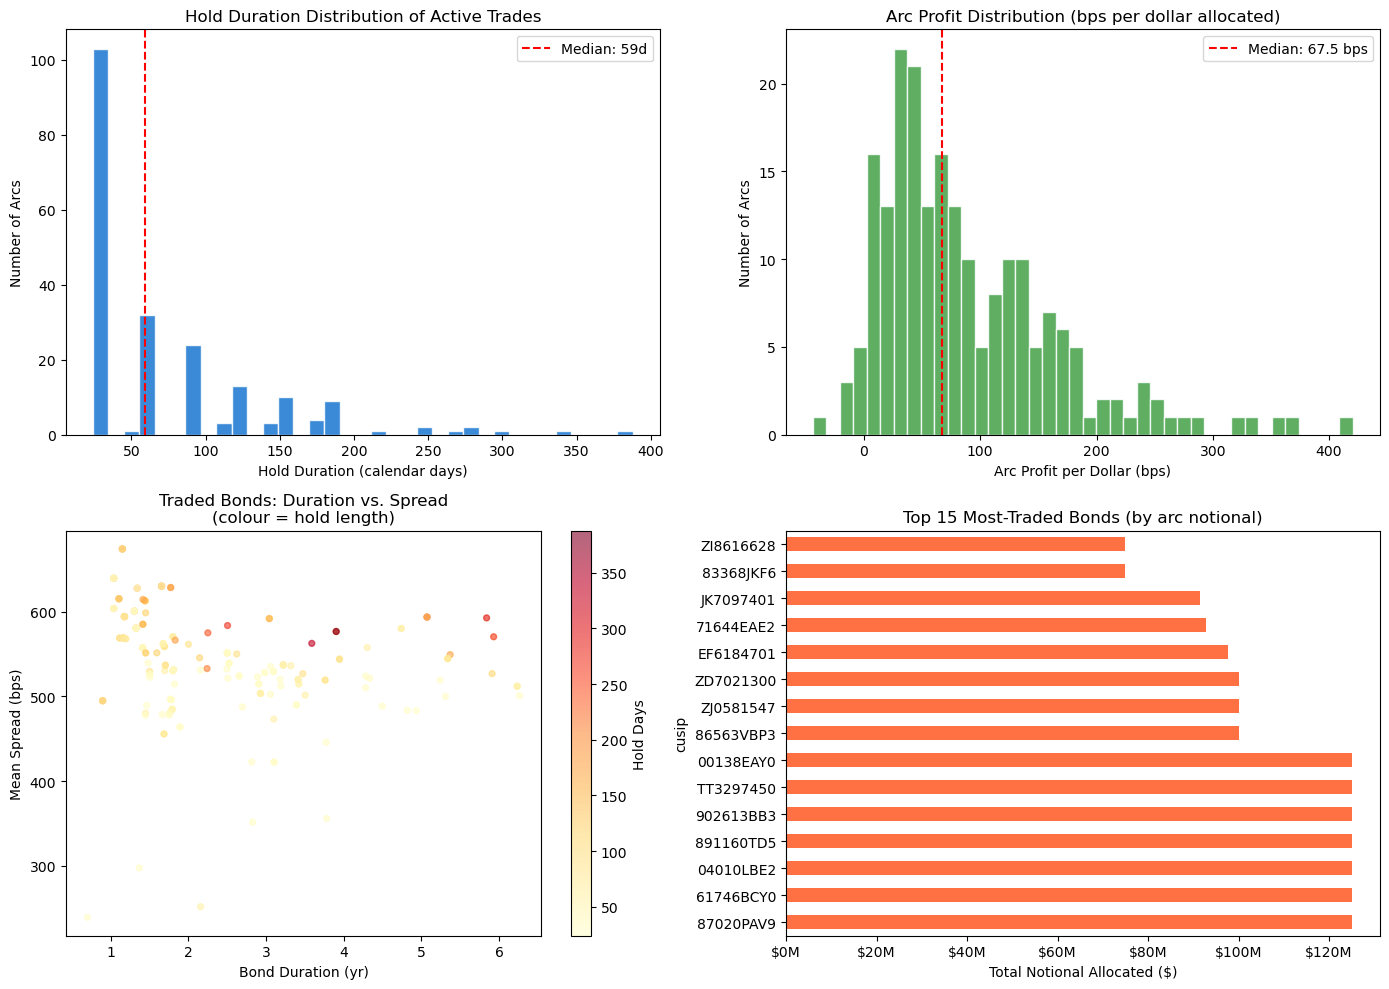


── Trend summary ──────────────────────────────────────────────
Mean hold duration      : 76 days
Median arc profit       : 67.5 bps/dollar
% arcs with profit > 0  : 95.3%
Correlation (hold, profit): 0.789
Top bond accounts for   : 7.8% of total arc notional


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# 5b. TRADE VISUALIZATIONS (runs only if trades_df was built above)
# ─────────────────────────────────────────────────────────────────────────────
if trades_df is not None and len(trades_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Hold-duration histogram
    ax = axes[0, 0]
    ax.hist(trades_df["hold_days"].clip(upper=400), bins=35,
            color="#1976D2", edgecolor="white", alpha=0.85)
    _med_hold = trades_df["hold_days"].median()
    ax.axvline(_med_hold, color="red", ls="--", label=f"Median: {_med_hold:.0f}d")
    ax.set_xlabel("Hold Duration (calendar days)")
    ax.set_ylabel("Number of Arcs")
    ax.set_title("Hold Duration Distribution of Active Trades")
    ax.legend()

    # 2. Arc profit distribution
    ax = axes[0, 1]
    _profits_bps = trades_df["arc_profit_per_dollar"] * 1e4
    ax.hist(_profits_bps[_profits_bps > _profits_bps.quantile(0.01)],
            bins=40, color="#43A047", edgecolor="white", alpha=0.85)
    _med_pf = _profits_bps.median()
    ax.axvline(_med_pf, color="red", ls="--", label=f"Median: {_med_pf:.1f} bps")
    ax.set_xlabel("Arc Profit per Dollar (bps)")
    ax.set_ylabel("Number of Arcs")
    ax.set_title("Arc Profit Distribution (bps per dollar allocated)")
    ax.legend()

    # 3. Duration vs mean spread, coloured by hold duration
    ax = axes[1, 0]
    _sc = ax.scatter(trades_df["duration_yr"], trades_df["spread_mean_bps"],
                     c=trades_df["hold_days"].clip(upper=400),
                     cmap="YlOrRd", alpha=0.6, s=18)
    plt.colorbar(_sc, ax=ax, label="Hold Days")
    ax.set_xlabel("Bond Duration (yr)")
    ax.set_ylabel("Mean Spread (bps)")
    ax.set_title("Traded Bonds: Duration vs. Spread\n(colour = hold length)")

    # 4. Top-15 bonds by total notional allocated
    ax = axes[1, 1]
    _top = (trades_df.groupby("cusip")["dollar_alloc"].sum()
                     .sort_values(ascending=False).head(15))
    _top.plot.barh(ax=ax, color="#FF5722", alpha=0.85)
    ax.set_xlabel("Total Notional Allocated ($)")
    ax.set_title("Top 15 Most-Traded Bonds (by arc notional)")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda _x, _: f"${_x/1e6:.0f}M"))

    plt.tight_layout(); plt.show()

    # Trend summary
    print("\n── Trend summary ──────────────────────────────────────────────")
    print(f"Mean hold duration      : {trades_df['hold_days'].mean():.0f} days")
    print(f"Median arc profit       : {_profits_bps.median():.1f} bps/dollar")
    print(f"% arcs with profit > 0  : {(trades_df['arc_profit_per_dollar'] > 0).mean()*100:.1f}%")
    _corr = trades_df[["hold_days","arc_profit_per_dollar"]].corr().iloc[0, 1]
    print(f"Correlation (hold, profit): {_corr:.3f}")
    print(f"Top bond accounts for   : "
          f"{_top.iloc[0]/_top.sum()*100:.1f}% of total arc notional")
else:
    print("trades_df not available — skipping trade visualizations.")
    print("Re-run Cell 5 after confirming arc field names.")


### Bond IMR Potential

Top 20 bonds by IMR potential proxy (spread_range × duration):


'    cusip rating_tier  yield_mean_bps  yield_range_bps  duration_yr  imr_proxy  imr_per_c1\n24422EXN4        A+/A          483.11           557.57         4.93    2750.50       33.71\n89236TLZ6        A+/A          483.55           564.30         4.82    2718.32       41.37\n459058JR5     AAA/AA+          421.05           495.61         5.45    2700.97      170.95\n66815M2S5     AAA/AA+          435.35           570.00         4.40    2510.77       92.65\n57629XDA3          AA          355.96           560.73         3.78    2119.68       50.59\nBW4937361     AAA/AA+          445.88           558.06         3.77    2105.83      133.28\n830505BB8        A+/A          514.77           605.62         3.42    2071.54       25.39\n02665WFE6          A-          491.01           576.00         3.42    1970.91       19.40\nZD2045866          AA          489.98           571.66         3.39    1937.81       37.05\nZJ0581547          AA          503.65           600.97         2.93    1759.21 

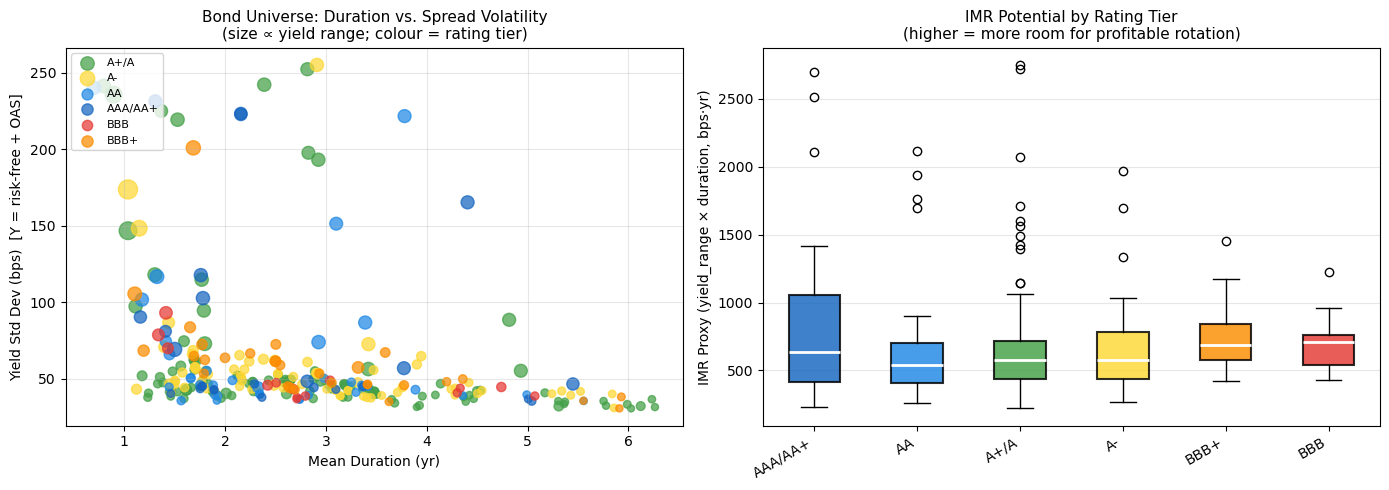


IMR potential per unit of C1 capital charge (by rating tier):


,imr_proxy,c1_factor,imr_per_c1
rating_tier,,,
AAA/AA+,886.20,0.00,426633.36
AA,670.02,0.01,132501.62
A+/A,662.52,0.01,88700.02
A-,648.14,0.01,57581.09
BBB+,731.62,0.02,48038.13
BBB,695.28,0.02,32069.89



→ Tiers with high imr_per_c1 generate the most IMR per dollar of regulatory capital.
  Prioritize these when loosening the concentration cap or duration band.


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# 6. BOND IMR POTENTIAL — rank every bond by its spread-volatility × duration
# This is a model-free proxy for IMR opportunity: bonds whose spreads swing
# widely AND whose duration is long offer the most to capture per round-trip.
# Runs unconditionally (no dependency on arc solution data).
# ─────────────────────────────────────────────────────────────────────────────

_spread_std   = np.nanstd(Y,  axis=0)
_spread_mean  = np.nanmean(Y, axis=0)
_spread_range = np.nanmax(Y,  axis=0) - np.nanmin(Y, axis=0)
_dur_mean     = np.nanmean(DUR, axis=0)

bond_imr = pd.DataFrame({
    "cusip"            : CUSIPS,
    "yield_mean_bps"   : _spread_mean  * 1e4,    # Y = risk-free + OAS; labelled yield, not pure spread
    "yield_std_bps"    : _spread_std   * 1e4,
    "yield_range_bps"  : _spread_range * 1e4,
    "duration_yr"      : _dur_mean,
    "c1_factor"        : THETA,
    # IMR proxy: range × duration (wider swing + longer hold = more to capture)
    "imr_proxy"        : _spread_range * _dur_mean * 1e4,    # yield_range × duration
    # Capital efficiency: IMR proxy per unit of C1 capital charge
    "imr_per_c1"       : (_spread_range * _dur_mean) / np.where(THETA > 0, THETA, np.nan),
})

# Approximate rating tier from NAIC C1 factors
def _c1_to_rating(t):
    if   t <= 0.004: return "AAA/AA+"
    elif t <= 0.006: return "AA"
    elif t <= 0.009: return "A+/A"
    elif t <= 0.013: return "A-"
    elif t <= 0.018: return "BBB+"
    elif t <= 0.030: return "BBB"
    else:            return "BBB-"

bond_imr["rating_tier"] = bond_imr["c1_factor"].apply(_c1_to_rating)

print("Top 20 bonds by IMR potential proxy (spread_range × duration):")
display(bond_imr.sort_values("imr_proxy", ascending=False)
                .head(20)[["cusip","rating_tier","yield_mean_bps",
                            "yield_range_bps","duration_yr","imr_proxy","imr_per_c1"]]
                .round(2).to_string(index=False))

# ── 2-panel chart ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

_tier_colors = {
    "AAA/AA+": "#1565C0", "AA": "#1E88E5", "A+/A": "#43A047",
    "A-": "#FDD835", "BBB+": "#FB8C00", "BBB": "#E53935", "BBB-": "#B71C1C",
}

# Panel 1: duration vs spread_std scatter, sized by range, coloured by rating
ax = axes[0]
for _tier, _grp in bond_imr.groupby("rating_tier"):
    _sz = (_grp["yield_range_bps"] / bond_imr["yield_range_bps"].max()) * 180 + 8
    ax.scatter(_grp["duration_yr"], _grp["yield_std_bps"],
               s=_sz, color=_tier_colors.get(_tier, "grey"),
               label=_tier, alpha=0.72)
ax.set_xlabel("Mean Duration (yr)")
ax.set_ylabel("Yield Std Dev (bps)  [Y = risk-free + OAS]")
ax.set_title("Bond Universe: Duration vs. Spread Volatility\n"
             "(size ∝ yield range; colour = rating tier)", fontsize=11)
ax.legend(fontsize=8, loc="upper left"); ax.grid(alpha=0.3)

# Panel 2: IMR proxy distribution by rating tier (box plot)
ax2 = axes[1]
_tier_order  = ["AAA/AA+", "AA", "A+/A", "A-", "BBB+", "BBB", "BBB-"]
_valid_tiers = [t for t in _tier_order if t in bond_imr["rating_tier"].values]
_data_tiers  = [bond_imr.loc[bond_imr["rating_tier"] == t, "imr_proxy"].values
                for t in _valid_tiers]
_bp = ax2.boxplot(_data_tiers, patch_artist=True,
                  boxprops=dict(linewidth=1.5),
                  medianprops=dict(color="white", linewidth=2))
for _patch, _t in zip(_bp["boxes"], _valid_tiers):
    _patch.set_facecolor(_tier_colors.get(_t, "grey")); _patch.set_alpha(0.82)
ax2.set_xticks(range(1, len(_valid_tiers) + 1))
ax2.set_xticklabels(_valid_tiers, rotation=30, ha="right")
ax2.set_ylabel("IMR Proxy (yield_range × duration, bps·yr)")
ax2.set_title("IMR Potential by Rating Tier\n"
              "(higher = more room for profitable rotation)", fontsize=11)
ax2.grid(alpha=0.3, axis="y")

plt.tight_layout(); plt.show()

# Which tier offers the most IMR per unit of C1 capital?
print("\nIMR potential per unit of C1 capital charge (by rating tier):")
_summary = (bond_imr.groupby("rating_tier")[["imr_proxy", "c1_factor"]]
                    .mean()
                    .assign(imr_per_c1=lambda df: df["imr_proxy"] / df["c1_factor"])
                    .sort_values("imr_per_c1", ascending=False)
                    .round(2))
display(_summary)
print("\n→ Tiers with high imr_per_c1 generate the most IMR per dollar of regulatory capital.")
print("  Prioritize these when loosening the concentration cap or duration band.")


---

## Trading Patterns, Issuer Stories & IMR/NII Time Series

Three additions requested in review:
1. **Trading intensity** — when does the foresight LP trade, and does it coincide with yield volatility?
2. **Issuer story** — transaction timelines for the top 3 most-traded bonds.
3. **IMR / NII time series** — Image-1-style three-panel chart reconstructed from arc solution.

> **Note on Cell 28 labelling:** `Y` in this notebook is the book yield (risk-free rate + OAS),
> not pure OAS. Column names and chart axes have been updated to "yield" accordingly.
> The IMR-potential intuition (wide yield swings × long duration = more to harvest) still holds.


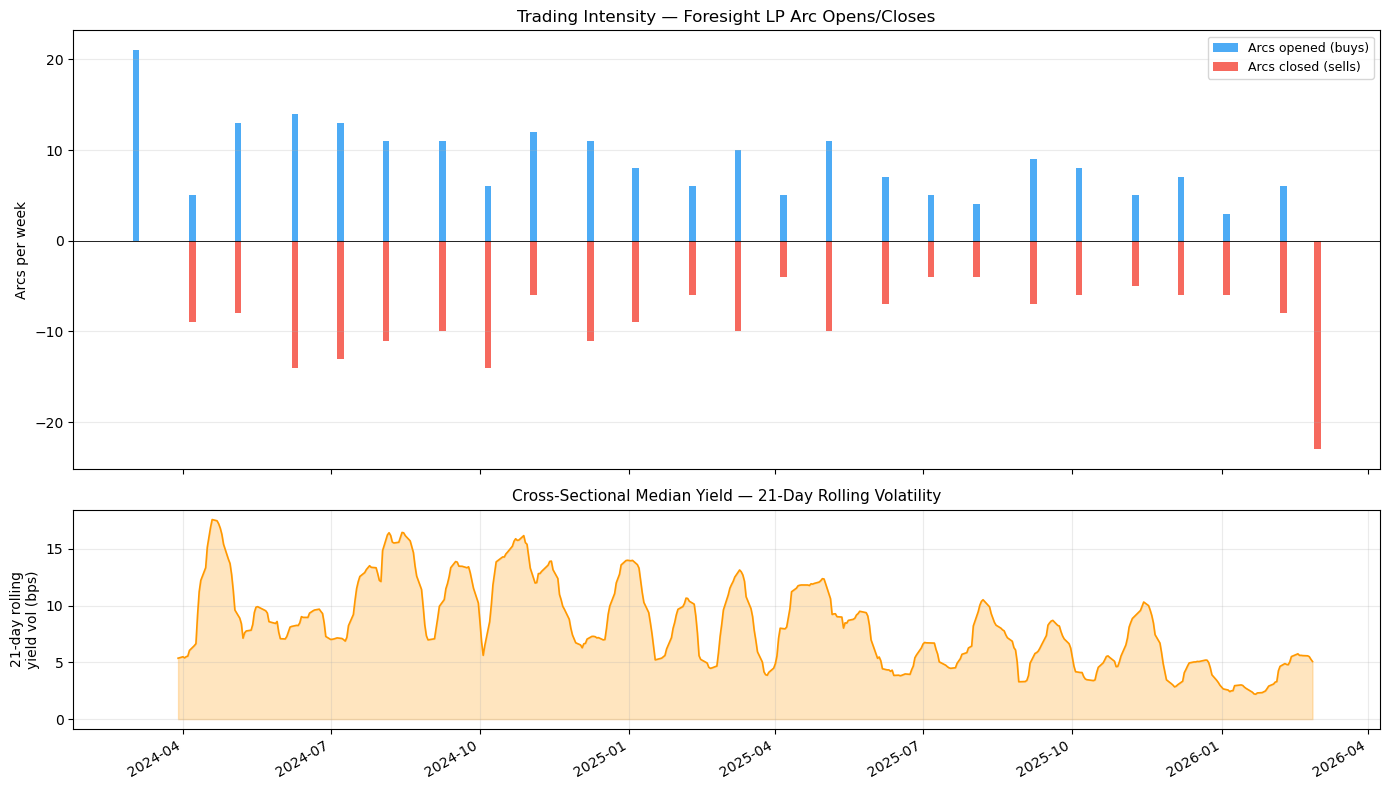

Pearson r (weekly arc opens vs 21d yield vol): 0.044
Top-10 trading weeks overlapping high-vol weeks: 9/10


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# 7. TRADING INTENSITY OVER TIME
# Top panel:  weekly arc opens (buys) and closes (sells) from the LP solution.
# Bottom panel: 21-day rolling yield volatility of the cross-sectional median.
# Hypothesis: peak trading coincides with peak volatility.
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.dates as mdates

if trades_df is None or len(trades_df) == 0:
    print("trades_df not available. Apply the field-name fix in Cell 25 first.")
else:
    # Weekly trade event counts
    _t_opens  = trades_df.set_index('buy_date').resample('W').size().rename('opens')
    _t_closes = trades_df.set_index('close_date').resample('W').size().rename('closes')
    _t_events = pd.concat([_t_opens, _t_closes], axis=1).fillna(0).astype(int)

    # 21-day rolling yield vol (cross-sectional median, then time-series vol)
    _med_yield = pd.Series(np.nanmedian(Y, axis=1), index=pd.DatetimeIndex(BT_DATES))
    _roll_vol  = _med_yield.rolling(21).std() * 1e4  # bps

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                    gridspec_kw={"height_ratios": [2, 1]})

    # ── Top: bars for opens / closes ─────────────────────────────────────────
    _w = pd.Timedelta(days=4)
    ax1.bar(_t_events.index, _t_events['opens'],   width=_w, color='#2196F3',
            alpha=0.8, label='Arcs opened (buys)')
    ax1.bar(_t_events.index, -_t_events['closes'], width=_w, color='#F44336',
            alpha=0.8, label='Arcs closed (sells)')
    ax1.axhline(0, color='black', lw=0.6)
    ax1.set_ylabel("Arcs per week")
    ax1.set_title("Trading Intensity — Foresight LP Arc Opens/Closes", fontsize=12)
    ax1.legend(loc='upper right', fontsize=9)
    ax1.grid(alpha=0.25, axis='y')

    # ── Bottom: rolling yield volatility ─────────────────────────────────────
    ax2.fill_between(_roll_vol.index, _roll_vol, alpha=0.25, color='#FF9800')
    ax2.plot(_roll_vol.index, _roll_vol, color='#FF9800', lw=1.2)
    ax2.set_ylabel("21-day rolling\nyield vol (bps)")
    ax2.set_title("Cross-Sectional Median Yield — 21-Day Rolling Volatility", fontsize=11)
    ax2.grid(alpha=0.25)

    for ax in (ax1, ax2):
        ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

    plt.tight_layout()
    plt.show()

    # Correlation
    _opens_w = _t_events['opens']
    _vol_w   = _roll_vol.resample('W').mean().dropna()
    _common  = _opens_w.index.intersection(_vol_w.index)
    _corr    = _opens_w[_common].corr(_vol_w[_common])
    print(f"Pearson r (weekly arc opens vs 21d yield vol): {_corr:.3f}")
    _high_vol = _roll_vol[_roll_vol > _roll_vol.quantile(0.75)]
    _high_vol_w = _high_vol.resample('W').mean().index
    _top_trade_w = _t_events['opens'].nlargest(10).index
    _overlap = len(_high_vol_w.intersection(_top_trade_w))
    print(f"Top-10 trading weeks overlapping high-vol weeks: {_overlap}/10")


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# 8. ISSUER NAMES
# ─────────────────────────────────────────────────────────────────────────────
# PIPELINE NOTE: to make issuer names permanent, add 'Issuer_name' to the
# Agg_Fixed_Field SELECT in fabn_pipeline.py, then regenerate prize_panels.npz.
# Example addition to the query:
#   SELECT CUSIP, Coupon, MaturityDate, Rating, Duration, Issuer_name, ...
#   FROM `{project}.{dataset}.Agg_Fixed_Field`
#
# Once regenerated, load with:  ISSUER_NAMES = z['ISSUER_NAMES']
# ─────────────────────────────────────────────────────────────────────────────
try:
    from google.cloud import bigquery as _bq_lib
    _bq = _bq_lib.Client(project=os.environ.get('GCP_PROJECT_ID'))
    _iq = (
        "SELECT CUSIP, Issuer_name "
        "FROM `{p}.{d}.Agg_Fixed_Field`"
    ).format(p=os.environ.get('GCP_PROJECT_ID', ''),
             d=os.environ.get('DATASET_ID', 'fabn'))
    _issuer_df  = _bq.query(_iq).to_dataframe()
    _issuer_map = dict(zip(_issuer_df['CUSIP'], _issuer_df['Issuer_name']))
    print(f"Loaded {len(_issuer_map)} issuer names from BigQuery.")
except Exception as _e:
    print(f"BigQuery lookup failed ({_e}) — using CUSIP as fallback until pipeline is updated.")
    _issuer_map = {c: c for c in CUSIPS}

if trades_df is not None:
    trades_df['issuer'] = trades_df['cusip'].map(_issuer_map).fillna('Unknown')
    bond_imr['issuer']  = bond_imr['cusip'].map(_issuer_map).fillna('Unknown')

    print("\nTop 15 most-traded issuers (by total arc notional):")
    display(
        trades_df.groupby(['issuer','cusip'])['dollar_alloc'].sum()
                 .sort_values(ascending=False)
                 .head(15)
                 .apply(lambda x: f"${x/1e6:.1f}M")
                 .reset_index()
                 .rename(columns={'dollar_alloc': 'arc_notional'})
    )


/opt/anaconda3/lib/python3.13/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


BigQuery lookup failed (404 Not found: Dataset insurance-backed-securities:fabn was not found in location US; reason: notFound, message: Not found: Dataset insurance-backed-securities:fabn was not found in location US

Location: US
Job ID: a35488de-6215-4bdd-b6a2-6fc1107a0648
) — using CUSIP as fallback until pipeline is updated.

Top 15 most-traded issuers (by total arc notional):


,issuer,cusip,arc_notional
0,87020PAV9,87020PAV9,$125.0M
1,61746BCY0,61746BCY0,$125.0M
2,04010LBE2,04010LBE2,$125.0M
3,891160TD5,891160TD5,$125.0M
4,902613BB3,902613BB3,$125.0M
5,TT3297450,TT3297450,$125.0M
6,00138EAY0,00138EAY0,$125.0M
7,86563VBP3,86563VBP3,$100.0M
8,ZJ0581547,ZJ0581547,$100.0M
9,ZD7021300,ZD7021300,$100.0M


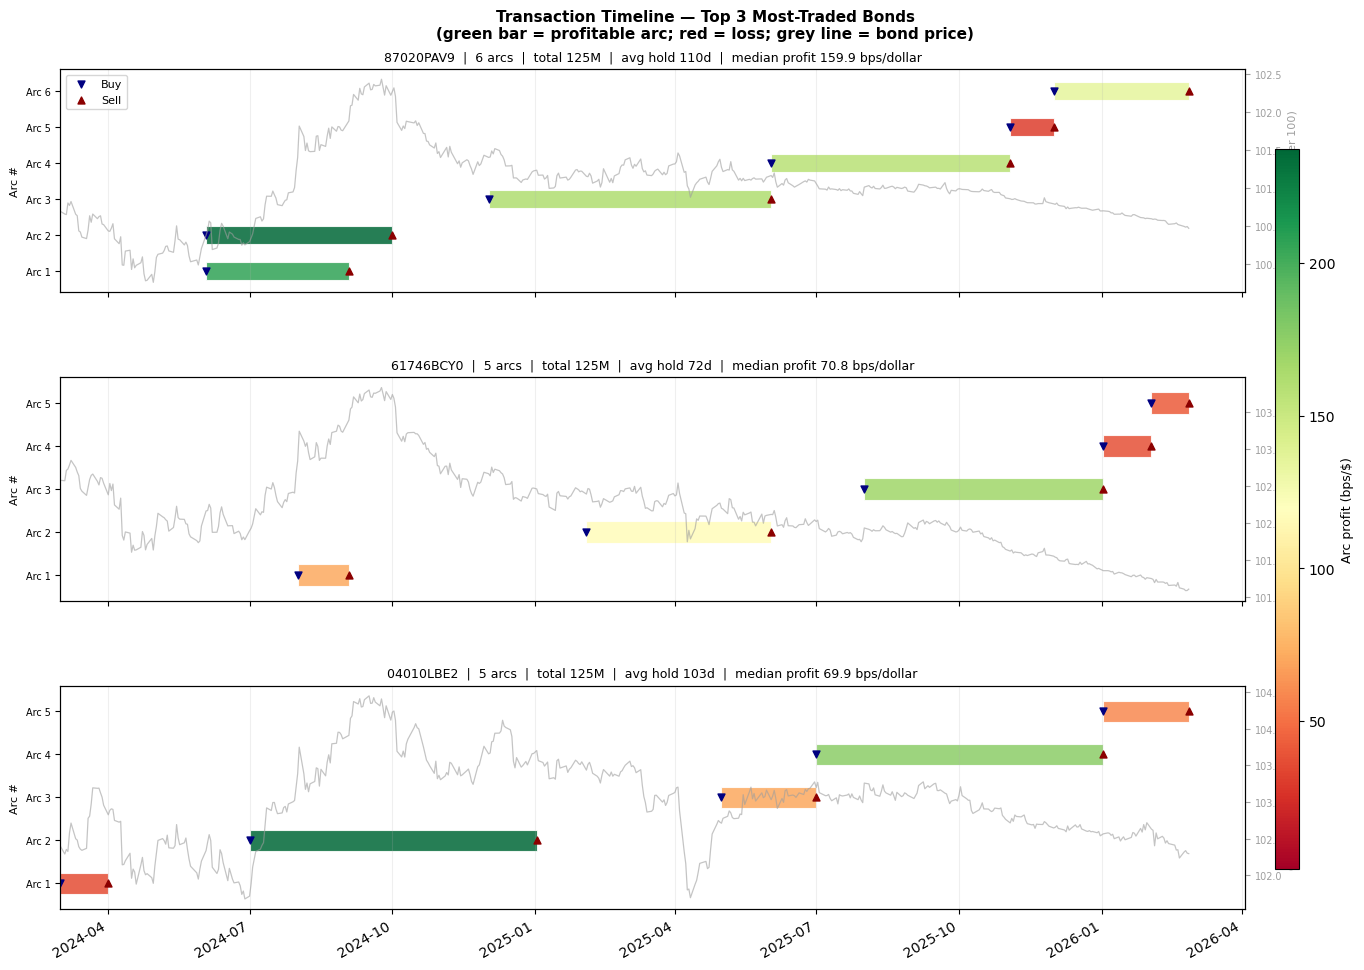

In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# 9. TRANSACTION TIMELINE — top 3 most-traded CUSIPs (Gantt-style)
# For each bond: shows the yield series (right axis) overlaid with buy/hold/close
# intervals (colored bars) so the "buy cheap / sell rich" pattern is visible.
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.dates as mdates
from matplotlib.cm import RdYlGn
from matplotlib.colors import Normalize

if trades_df is None or len(trades_df) == 0:
    print("trades_df not available — apply Cell 25 fix first.")
else:
    _top3 = (trades_df.groupby('cusip')['dollar_alloc'].sum()
                      .sort_values(ascending=False).head(3).index.tolist())

    _norm = Normalize(
        vmin=trades_df['arc_profit_per_dollar'].quantile(0.05) * 1e4,
        vmax=trades_df['arc_profit_per_dollar'].quantile(0.95) * 1e4,
    )

    fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
    fig.subplots_adjust(left=0.07, right=0.86, top=0.92, bottom=0.08, hspace=0.38)

    for _i, _cusip in enumerate(_top3):
        ax = axes[_i]
        _bt = trades_df[trades_df['cusip'] == _cusip].sort_values('buy_date')
        _bidx = int(_bt['bond_idx'].iloc[0])
        _issuer = _bt['issuer'].iloc[0] if 'issuer' in _bt.columns else _cusip

        # Clean price series (right axis) — Bloomberg PX_MID is clean price
        _ax2 = ax.twinx()
        _yseries = pd.Series(MID[:, _bidx], index=pd.DatetimeIndex(BT_DATES))
        _ax2.plot(_yseries.index, _yseries.values, color='#9E9E9E', lw=0.9,
                  alpha=0.6, label='Clean mid price')
        _ax2.set_ylabel("Clean mid price (per 100)", color='#9E9E9E', fontsize=8)
        _ax2.tick_params(axis='y', colors='#9E9E9E', labelsize=7)

        # Hold intervals as horizontal bars (y = arc index, spaced vertically)
        for _j, (_, _row) in enumerate(_bt.iterrows()):
            _profit_bps = _row['arc_profit_per_dollar'] * 1e4
            _color = RdYlGn(_norm(_profit_bps))
            _dur_days = (_row['close_date'] - _row['buy_date']).days
            ax.barh(_j, _dur_days, left=_row['buy_date'],
                height=0.5, color=_color, alpha=0.85,
                edgecolor='white', linewidth=0.8)
            ax.scatter(_row['buy_date'],  _j, color='navy', s=25, zorder=5,
                       marker='v', label='Buy'  if _j == 0 else '')
            ax.scatter(_row['close_date'],_j, color='darkred', s=25, zorder=5,
                       marker='^', label='Sell' if _j == 0 else '')

        ax.set_ylabel(f"Arc #", fontsize=8)
        _lbl = (
            f"{_cusip}"
            + (f"  [{_issuer}]" if _issuer != _cusip else "")
            + f"  |  {len(_bt)} arcs"
            + f"  |  total {_bt['dollar_alloc'].sum()/1e6:.0f}M"
            + f"  |  avg hold {_bt['hold_days'].mean():.0f}d"
            + f"  |  median profit {_bt['arc_profit_per_dollar'].median()*1e4:.1f} bps/dollar"
        )
        ax.set_title(_lbl, fontsize=9)
        ax.set_yticks(range(len(_bt)))
        ax.set_yticklabels([f"Arc {k+1}" for k in range(len(_bt))], fontsize=7)
        ax.set_ylim(-0.6, len(_bt) - 0.4)
        if _i == 0:
            ax.legend(fontsize=8, loc='upper left')
        ax.grid(alpha=0.2, axis='x')

    axes[-1].xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha='right')

    # Colorbar: manual cax avoids the twinx layout conflict
    _sm = plt.cm.ScalarMappable(cmap=RdYlGn, norm=_norm)
    _sm.set_array([])
    _cax = fig.add_axes([0.88, 0.12, 0.016, 0.72])   # [left, bottom, width, height]
    _cbar = fig.colorbar(_sm, cax=_cax)
    _cbar.set_label("Arc profit (bps/$)", fontsize=9)

    plt.suptitle("Transaction Timeline — Top 3 Most-Traded Bonds\n"
                 "(green bar = profitable arc; red = loss; grey line = bond price)",
                 fontsize=11, fontweight='bold')
    plt.show()

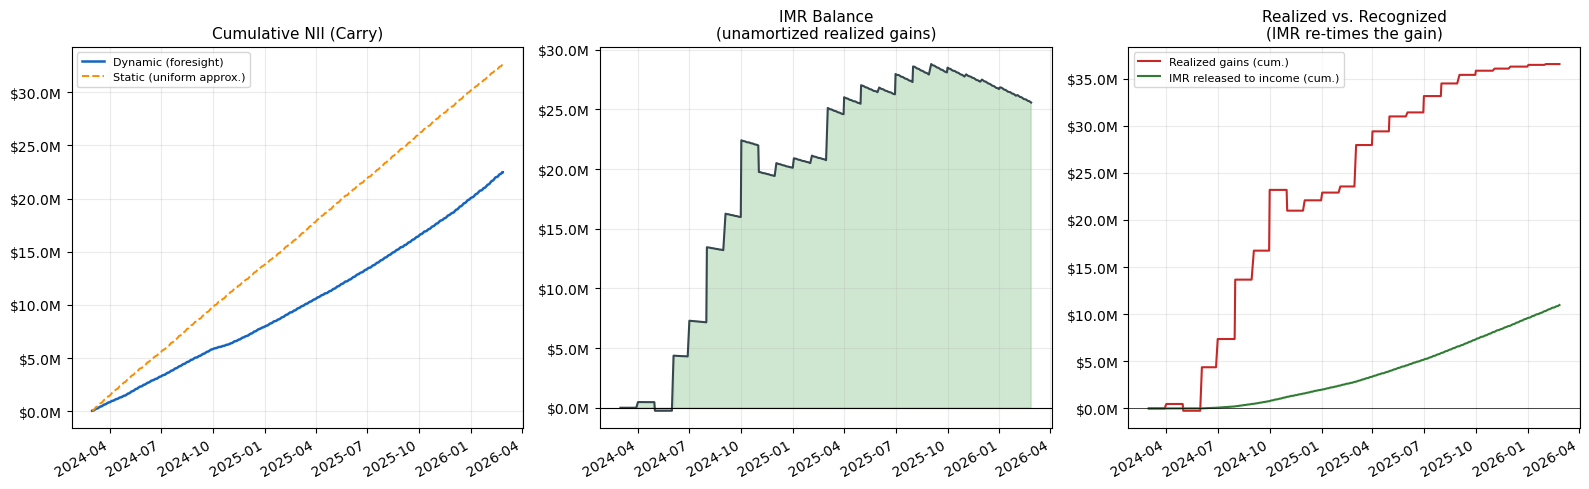

Monthly NII accrual vs IMR realization correlation: -0.411
(Negative = selling bonds stops carry while generating IMR, as hypothesised)


In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# 10. IMR / NII TIME SERIES — Image-1 equivalent for the foresight LP
# Reconstructs three panels from the arc solution:
#   Left:   Cumulative NII (carry accrued daily from active arcs)
#   Middle: IMR balance = unreleased realized gains at each date
#   Right:  Realized gains (step function) vs IMR released to income (smooth)
#
# Key insight to test: do IMR spikes and NII growth correlate?
# Intuition: selling a bond generates IMR but *stops* its carry → may anti-correlate.
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

_FABN_MAT = pd.Timestamp('2027-09-06')   # FABN maturity (Series 2022-6)
_dates    = pd.DatetimeIndex(BT_DATES)

# Pull active arc arrays directly from arcs_dyn / dyn
_act = np.asarray(dyn['x']) > 1.0
_ba2  = np.asarray(arcs_dyn['i'])[_act]
_bya2 = np.asarray(arcs_dyn['p_buy'])[_act]
_cla2 = np.asarray(arcs_dyn['p_close'])[_act]
_cr2  = np.asarray(arcs_dyn['carry'])[_act]       # carry per dollar
_iw2  = np.asarray(arcs_dyn['imr_full'])[_act]    # IMR per dollar (full, including post-window)
_x2   = np.asarray(dyn['x'])[_act]                # dollar allocation

# Pre-allocate daily series
_nii_d   = pd.Series(0.0, index=_dates)    # daily carry accrual
_real_d  = pd.Series(0.0, index=_dates)    # IMR realized at close
_rlsd_d  = pd.Series(0.0, index=_dates)    # IMR released to income (daily)

for _k in range(len(_x2)):
    _bd  = pd.Timestamp(BT_DATES[grid_m[_bya2[_k]]])
    _cd  = pd.Timestamp(BT_DATES[grid_m[_cla2[_k]]])
    _hd  = (_cd - _bd).days
    if _hd <= 0:
        continue

    # --- carry: distribute uniformly over hold period ---
    _carry_usd = float(_cr2[_k]) * float(_x2[_k])
    _mask_h  = (_dates >= _bd) & (_dates < _cd)
    _nii_d[_mask_h] += _carry_usd / _hd

    # --- IMR: realized as a lump at close date ---
    _imr_usd = float(_iw2[_k]) * float(_x2[_k])
    _cl_loc = _dates.searchsorted(_cd)
    if _cl_loc < len(_dates):
        _real_d.iloc[_cl_loc] += _imr_usd

    # --- IMR amortisation: linear from close to FABN maturity ---
    _days_left = (_FABN_MAT - _cd).days
    if _days_left > 0:
        _daily_rel = _imr_usd / _days_left
        _mask_rel  = (_dates >= _cd)
        _rlsd_d[_mask_rel] += _daily_rel

# Cumulative series
_cum_nii  = _nii_d.cumsum()
_cum_real = _real_d.cumsum()
_cum_rlsd = _rlsd_d.cumsum()
_imr_bal  = _cum_real - _cum_rlsd   # unreleased IMR sitting in the "account"

_M = FuncFormatter(lambda v, _: f'${v/1e6:.1f}M')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Left: Cumulative NII ────────────────────────────────────────────────────
ax = axes[0]
ax.plot(_cum_nii.index, _cum_nii.values, color='#1565C0', lw=1.8,
        label='Dynamic (foresight)')
# Static NII: uniform accrual of sta decomp carry
_static_carry_daily = sta['decomp']['carry'] / len(_dates)
_cum_static = pd.Series(
    np.arange(1, len(_dates)+1) * _static_carry_daily, index=_dates)
ax.plot(_cum_static.index, _cum_static.values, color='#FB8C00',
        ls='--', lw=1.4, label='Static (uniform approx.)')
ax.yaxis.set_major_formatter(_M)
ax.set_title("Cumulative NII (Carry)", fontsize=11)
ax.legend(fontsize=8); ax.grid(alpha=0.25)

# ── Middle: IMR balance ─────────────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(_imr_bal.index, _imr_bal.values, color='#37474F', lw=1.5)
ax2.fill_between(_imr_bal.index, _imr_bal.values,
                 where=(_imr_bal.values < 0), alpha=0.25, color='#F44336')
ax2.fill_between(_imr_bal.index, _imr_bal.values,
                 where=(_imr_bal.values >= 0), alpha=0.25, color='#43A047')
ax2.axhline(0, color='black', lw=0.8)
ax2.yaxis.set_major_formatter(_M)
ax2.set_title("IMR Balance\n(unamortized realized gains)", fontsize=11)
ax2.grid(alpha=0.25)

# ── Right: Realized vs Recognized ──────────────────────────────────────────
ax3 = axes[2]
ax3.plot(_cum_real.index, _cum_real.values, color='#C62828', lw=1.5,
         label='Realized gains (cum.)')
ax3.plot(_cum_rlsd.index, _cum_rlsd.values, color='#2E7D32', lw=1.5,
         label='IMR released to income (cum.)')
ax3.axhline(0, color='black', lw=0.5)
ax3.yaxis.set_major_formatter(_M)
ax3.set_title("Realized vs. Recognized\n(IMR re-times the gain)", fontsize=11)
ax3.legend(fontsize=8); ax3.grid(alpha=0.25)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

# Correlation check: are monthly NII growth and IMR realization correlated?
_nii_monthly  = _nii_d.resample('ME').sum()
_real_monthly = _real_d.resample('ME').sum()
_corr_nii_imr = _nii_monthly.corr(_real_monthly)
print(f"Monthly NII accrual vs IMR realization correlation: {_corr_nii_imr:.3f}")
print("(Negative = selling bonds stops carry while generating IMR, as hypothesised)")


BID/ASK SPREAD SENSITIVITY  (weekly grid)


,spread_pct,label,prize_window_M,prize_full_M,static_M,gap_vs_static_M,txn_cost_M,imr_window_M,traded_notional_M,pct_of_frictionless
0,0,0%,81.65,172.99,29.86,51.79,0.00,55.67,40530.34,100.0
1,25,25%,70.43,146.15,29.64,40.79,8.61,52.09,28042.32,86.3
2,50,50%,63.28,129.71,29.43,33.85,12.12,47.75,21979.51,77.5
3,75,75%,58.04,117.31,29.23,28.81,13.86,43.64,18301.86,71.1
4,100,100% (live),54.00,106.29,29.04,24.97,14.11,39.52,15188.95,66.1



Live (100%) keeps 66% of the frictionless (0%) prize; spread costs $27.6M.


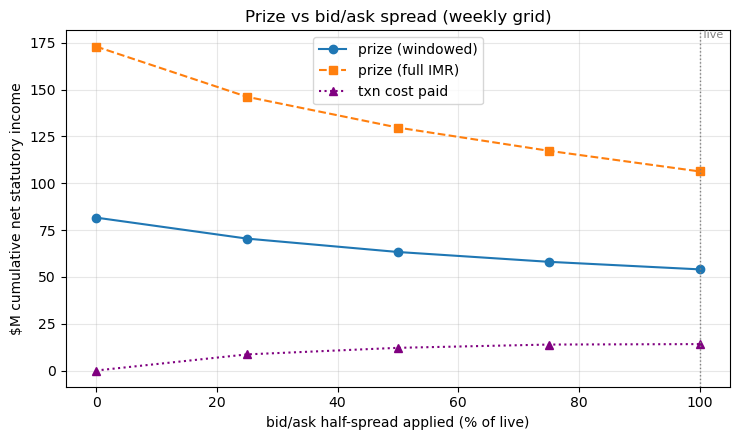

In [28]:
#%% TEST A — BID/ASK SPREAD SENSITIVITY (weekly grid)
# ==============================================================================
# Live market half-spread = TAU (=(ask-bid)/(2*mid)).  Scale it 0/25/50/75/100%
# to see how much of the prize the spread eats.  100% = live, 0% = frictionless
# ceiling.  Weekly grid keeps runtime modest (same finest point as the sweep).
# ==============================================================================

SPREAD_GRID = build_grid_every(5)               # weekly
_sinp = make_inputs(SPREAD_GRID)

def run_grid_spread(grid, inp, tau_mult, enforce=True):
    """run_grid, but multiply the live half-spread TAU by `tau_mult`."""
    TAU_use = TAU * float(tau_mult)
    common = dict(grid=grid, t_grid=inp["t_grid"], t_mat=t_mat, Y=Y, MID=MID, TAU=TAU_use,
                  THETA=THETA, ELIG=ELIG, lam=LAMBDA, r_fabn=r_FABN, window_end=window_end,
                  fabn_mat_yr=fabn_mat_yr, allow_post_fabn=PARAMS["allow_post_fabn"])
    arcs_d = pf.build_arcs(**common)
    arcs_s = pf.build_arcs(**common, buy_nodes={0})
    sv = dict(H=H, P=inp["P"], N=N, DUR_grid=inp["DUR_grid"], d_fabn_grid=inp["d_fabn_grid"],
              issuer_groups=issuer_groups, eps_D=PARAMS["eps_D"], dur_pen=PARAMS["dur_pen"],
              delta_iss=PARAMS["delta_iss"], enforce_duration=enforce, enforce_issuer=enforce,
              facility=None, env=GENV)
    return pf.solve_prize(arcs_d, **sv), pf.solve_prize(arcs_s, **sv)

spread_rows = []
for pct in (0, 25, 50, 75, 100):
    d, s = run_grid_spread(SPREAD_GRID, _sinp, pct/100.0)
    assert d["status"] == "OPTIMAL", f"spread {pct}%: {d['status']}"
    dc = d["decomp"]
    spread_rows.append(dict(
        spread_pct        = pct,
        label             = f"{pct}%" + (" (live)" if pct == 100 else ""),
        prize_window_M    = d["prize_window"] / 1e6,
        prize_full_M      = d["prize_full"]   / 1e6,
        static_M          = s["prize_window"] / 1e6,
        gap_vs_static_M   = (d["prize_window"] - s["prize_window"]) / 1e6,
        txn_cost_M        = dc["cost"]        / 1e6,
        imr_window_M      = dc["imr_window"]  / 1e6,
        traded_notional_M = d["traded_notional"] / 1e6,
    ))
spread = pd.DataFrame(spread_rows)
_p0 = spread.loc[spread.spread_pct == 0, "prize_window_M"].iloc[0]          # frictionless
spread["pct_of_frictionless"] = (100 * spread["prize_window_M"] / _p0).round(1)

print("BID/ASK SPREAD SENSITIVITY  (weekly grid)")
display(spread.round(2))
print(f"\nLive (100%) keeps {spread.loc[spread.spread_pct==100,'pct_of_frictionless'].iloc[0]:.0f}% "
      f"of the frictionless (0%) prize; "
      f"spread costs ${(_p0 - spread.loc[spread.spread_pct==100,'prize_window_M'].iloc[0]):.1f}M.")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(spread["spread_pct"], spread["prize_window_M"], "o-",  label="prize (windowed)")
ax.plot(spread["spread_pct"], spread["prize_full_M"],   "s--", label="prize (full IMR)")
ax.plot(spread["spread_pct"], spread["txn_cost_M"],     "^:",  color="purple", label="txn cost paid")
ax.axvline(100, color="grey", ls=":", lw=1)
ax.annotate(" live", (100, ax.get_ylim()[1]), va="top", fontsize=8, color="grey")
ax.set_xlabel("bid/ask half-spread applied (% of live)")
ax.set_ylabel("$M cumulative net statutory income")
ax.set_title("Prize vs bid/ask spread (weekly grid)")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

consistency OK: in-cell copy == engine ($54.00M windowed)

TURNOVER (TRADED-NOTIONAL) CAP SENSITIVITY  (weekly grid)


,cap,cap_xbook,prize_window_M,prize_full_M,carry_M,imr_window_M,txn_cost_M,traded_notional_M,turnover_x,pct_of_unlimited
0,1x book,1.0,36.81,42.76,37.13,4.20,1.70,500.00,1.00,68.2
1,2x book,2.0,40.17,50.89,37.25,7.68,2.11,1000.00,2.00,74.4
2,5x book,5.0,45.34,63.71,35.45,16.18,3.78,2500.00,5.00,84.0
3,unlimited (live),inf,54.00,106.29,30.78,39.52,14.11,15188.95,30.38,100.0



At just 1x book turnover you already capture 68% of the unlimited prize; the jump from 2x→unlimited adds only $13.8M.


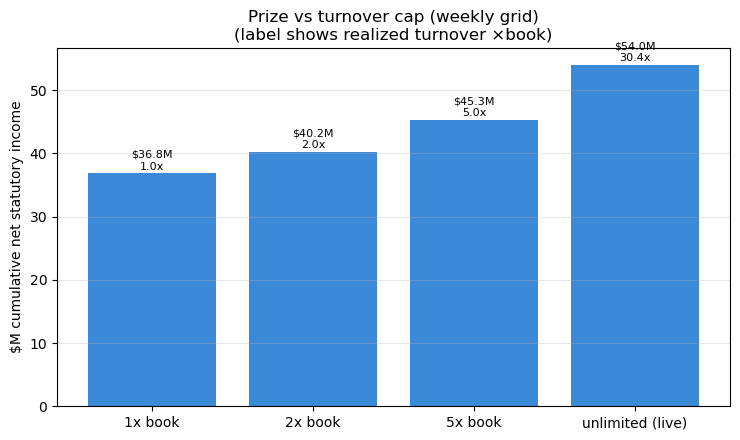

In [29]:
#%% TEST B — TURNOVER (TRADING-VOLUME) CAP (weekly grid)
# ==============================================================================
# How much churn does the prize actually need?  Cap total *traded notional*
# (= Σ dollars through arcs SOLD before maturity — the SAME quantity solve_prize
#  returns as `traded_notional`) at 1x / 2x / 5x / unlimited of book value H.
# 1x ≈ deploy once, barely flip;  unlimited = live headline.
# solve_prize has no turnover knob, so this cell adds ONE constraint on top of an
# EXACT copy of its model (the module is untouched).  We assert the uncapped copy
# reproduces the real engine, so the capped numbers are trustworthy.
# ==============================================================================

import gurobipy as gp
from gurobipy import GRB

TURN_GRID = build_grid_every(5)                 # weekly, same as Test A
_tinp = make_inputs(TURN_GRID)
_tcommon = dict(grid=TURN_GRID, t_grid=_tinp["t_grid"], t_mat=t_mat, Y=Y, MID=MID, TAU=TAU,
                THETA=THETA, ELIG=ELIG, lam=LAMBDA, r_fabn=r_FABN, window_end=window_end,
                fabn_mat_yr=fabn_mat_yr, allow_post_fabn=PARAMS["allow_post_fabn"])
ARCS_T = pf.build_arcs(**_tcommon)
_SV = dict(H=H, P=_tinp["P"], N=N, DUR_grid=_tinp["DUR_grid"], d_fabn_grid=_tinp["d_fabn_grid"],
           issuer_groups=issuer_groups, eps_D=PARAMS["eps_D"], dur_pen=PARAMS["dur_pen"],
           delta_iss=PARAMS["delta_iss"], enforce_duration=True, enforce_issuer=True,
           facility=None, env=GENV)

def solve_prize_turnover(arcs, turnover_cap=None, *, H, P, N, DUR_grid, d_fabn_grid,
                         issuer_groups, eps_D, dur_pen, delta_iss,
                         enforce_duration, enforce_issuer, facility, env):
    """EXACT copy of pf.solve_prize's model + ONE optional constraint:
         Σ_{sold arcs} x_a <= turnover_cap     (matches `traded_notional`).
    facility is accepted for signature parity but ignored (headline = facility off)."""
    na = arcs["n_arcs"]
    m = gp.Model("prize_turnover", env=env) if env is not None else gp.Model("prize_turnover")
    m.Params.OutputFlag = 0
    m.Params.DualReductions = 0
    x = m.addVars(na, lb=0.0)
    
    # --- book-value conservation (time-expanded flow) ---
    buys_at  = [gp.LinExpr() for _ in range(P)]
    frees_at = [gp.LinExpr() for _ in range(P + 1)]
    for a in range(na):
        buys_at[int(arcs["p_buy"][a])] += x[a]
        cl = int(arcs["p_close"][a])
        if cl <= P:
            frees_at[min(cl, P)] += x[a]
    m.addConstr(buys_at[0] <= float(H))
    running = float(H) - buys_at[0]
    for p in range(1, P):
        running = running + frees_at[p]
        m.addConstr(buys_at[p] <= running)
        running = running - buys_at[p]
        
    # --- per-interval holdings cover ---
    cover = [[] for _ in range(P)]
    for a in range(na):
        for p in range(int(arcs["p_buy"][a]), min(int(arcs["p_close"][a]), P)):
            cover[p].append(a)
            
    # --- soft duration band ---
    breach = gp.LinExpr()
    if enforce_duration and DUR_grid is not None and d_fabn_grid is not None:
        for p in range(P):
            dd = gp.LinExpr()
            for a in cover[p]:
                dd += DUR_grid[p, arcs["i"][a]] * x[a]
            dp = m.addVar(lb=0.0); dn = m.addVar(lb=0.0)
            ep = m.addVar(lb=0.0); en = m.addVar(lb=0.0)
            m.addConstr(dd - d_fabn_grid[p] * H == dp - dn)
            m.addConstr(dp <= eps_D * H + ep)
            m.addConstr(dn <= eps_D * H + en)
            breach += ep + en
            
    # --- issuer concentration cap ---
    if enforce_issuer and issuer_groups:
        for p in range(P):
            present = {}
            for a in cover[p]:
                present.setdefault(arcs["i"][a], []).append(a)
            for grp, members in issuer_groups.items():
                e = gp.LinExpr(); hit = False
                for i in members:
                    if i in present:
                        hit = True
                        for a in present[i]:
                            e += x[a]
                if hit:
                    m.addConstr(e <= delta_iss * H)
                    
    # >>> the ONE added constraint: turnover (traded-notional) cap <<<
    if turnover_cap is not None:
        m.addConstr(gp.quicksum(x[a] for a in range(na) if arcs["sold"][a]) <= float(turnover_cap))
        
    # --- objective (no facility term; headline) ---
    m.setObjective(gp.quicksum(float(arcs["coef"][a]) * x[a] for a in range(na))
                   - dur_pen * breach, GRB.MAXIMIZE)
    m.optimize()
    if m.Status != GRB.OPTIMAL:
        return {"status": f"GRB_{m.Status}", "prize_window": None}
    xv = np.array([x[a].X for a in range(na)])
    dec = dict(carry=float(np.sum(arcs["carry"] * xv)), capital=float(np.sum(arcs["capital"] * xv)),
               cost=float(np.sum(arcs["cost"] * xv)), imr_window=float(np.sum(arcs["imr_window"] * xv)),
               imr_full=float(np.sum(arcs["imr_full"] * xv)))
    base = dec["carry"] - dec["capital"] - dec["cost"]
    return dict(status="OPTIMAL", prize_window=base + dec["imr_window"],
                prize_full=base + dec["imr_full"], decomp=dec,
                traded_notional=float(np.sum(xv[arcs["sold"]])))

# consistency: my uncapped copy must reproduce the real engine on this grid
_ref = pf.solve_prize(ARCS_T, **_SV)
_chk = solve_prize_turnover(ARCS_T, turnover_cap=None, **_SV)
assert abs(_ref["prize_window"] - _chk["prize_window"]) < 1.0, \
    f"in-cell copy diverged from engine: {_ref['prize_window']:.0f} vs {_chk['prize_window']:.0f}"
print(f"consistency OK: in-cell copy == engine (${_chk['prize_window']/1e6:.2f}M windowed)\n")

turn_rows = []
for label, mult in [("1x book", 1.0), ("2x book", 2.0), ("5x book", 5.0), ("unlimited (live)", None)]:
    cap = None if mult is None else mult * H
    r = solve_prize_turnover(ARCS_T, turnover_cap=cap, **_SV)
    assert r["status"] == "OPTIMAL", f"{label}: {r['status']}"
    dc = r["decomp"]
    turn_rows.append(dict(
        cap               = label,
        cap_xbook         = (mult if mult is not None else np.inf),
        prize_window_M    = r["prize_window"] / 1e6,
        prize_full_M      = r["prize_full"]   / 1e6,
        carry_M           = dc["carry"]       / 1e6,
        imr_window_M      = dc["imr_window"]  / 1e6,
        txn_cost_M        = dc["cost"]        / 1e6,
        traded_notional_M = r["traded_notional"] / 1e6,
        turnover_x        = r["traded_notional"] / H,
    ))
turnover = pd.DataFrame(turn_rows)
_pmax = turnover["prize_window_M"].iloc[-1]      # unlimited row
turnover["pct_of_unlimited"] = (100 * turnover["prize_window_M"] / _pmax).round(1)
# the unlimited copy must equal the real engine (sanity)
assert abs(_pmax - _ref["prize_window"] / 1e6) < 1e-3

print("TURNOVER (TRADED-NOTIONAL) CAP SENSITIVITY  (weekly grid)")
display(turnover.round(2))
print(f"\nAt just 1x book turnover you already capture "
      f"{turnover['pct_of_unlimited'].iloc[0]:.0f}% of the unlimited prize; "
      f"the jump from 2x→unlimited adds only "
      f"${_pmax - turnover['prize_window_M'].iloc[1]:.1f}M.")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
_xpos = np.arange(len(turnover))
ax.bar(_xpos, turnover["prize_window_M"], color="#1976D2", alpha=0.85)
for _i, (_p, _t) in enumerate(zip(turnover["prize_window_M"], turnover["turnover_x"])):
    ax.text(_i, _p + 0.3, f"${_p:.1f}M\n{_t:.1f}x", ha="center", va="bottom", fontsize=8)
ax.set_xticks(_xpos); ax.set_xticklabels(turnover["cap"])
ax.set_ylabel("$M cumulative net statutory income")
ax.set_title("Prize vs turnover cap (weekly grid)\n(label shows realized turnover ×book)")
ax.grid(alpha=0.3, axis="y"); plt.tight_layout(); plt.show()